In [2]:
from scipy.optimize import minimize
from scipy import stats
from scipy import linalg
import numpy as np
import functools
import networkx as nx
import tqdm
import collections
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

import graph_tool.all as gt

Plotting/analysis helpers

In [3]:
def plot_matrix(W: np.ndarray):
    """ Plots a connectivity matrix

    Args:
        W: a weight matrix

    """

    W_extreme_val = np.percentile(np.abs(W[W != 0]), 95) * 1.01
    fig, ax = plt.subplots(figsize=(5, 5), dpi=150)
    im = ax.imshow(W, vmin=-W_extreme_val, vmax=W_extreme_val, cmap="bwr")

    ax.set_ylabel("Postsynaptic neurons", fontsize=12)
    ax.set_xlabel("Presynaptic neurons", fontsize=12)

    cbar = fig.colorbar(im, ax=ax, shrink=.5)
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label('Weight (AU)', labelpad=15)

    plt.show()


def plot_synapse_size_distribution(W: np.ndarray, non_zero_only: bool=True):
    """ Plots the distribution of synapse sizes

    Args:
        W: a weight matrix
        non_zero_only: If True, zero weights are not included in the plot

    """


    weights = W.flatten()

    if non_zero_only:
        weights = weights[weights != 0]

    W_extreme_val = np.percentile(np.abs(weights[weights != 0]), 99) * 1.01

    fig, ax = plt.subplots(figsize=(6, 3), dpi=150)

    sns.histplot(x=weights, bins=np.linspace(-W_extreme_val, W_extreme_val, 101), ax=ax)
    ax.set_xlabel("Weight (AU)", fontsize=12)
    ax.set_ylabel("Connection count", fontsize=12)
    plt.show()

In [4]:
def input_balance_excitation_inhibition(W: np.ndarray, n_neurons_exc: int, inh_exc_balance: float=1):
    """ Balances E and I on the input side of every neuron

    Args:
        W: a weight matrix
        n_neurons_exc: number of excitatory neurons in the matrix (first n_neurons_exc are assumed to be the excitatory neurons)
        inh_exc_balance: how to balabce E and I. A value of 1 balances E and I equally; a lower value will weight E higher.

    Returns:
        W_bal: a balanced weight matrix
    """
    W_bal = W.copy()

    per_neuron_exc_input_sum = np.sum(W[:, :n_neurons_exc], axis=1)
    per_neuron_inh_input_sum = np.sum(W[:, n_neurons_exc:], axis=1)

    per_neuron_inh_input_sum[per_neuron_inh_input_sum == 0] = 1 # stable behavior

    inh_scale_up = per_neuron_exc_input_sum / -per_neuron_inh_input_sum * inh_exc_balance
    W_bal[:, n_neurons_exc:] *= inh_scale_up[:, None]
    return W_bal


def generate_random_connectivity_matrix(n_neurons: int, r_inhibitory: float, g: float, connectivity_proba: float,
                                        random_seed: int, balance_W: bool=True, inh_exc_balance: float=1):
    """ Generates random connectivity matrix

    Args:
        n_neurons: number of neurons
        r_inhibitory: ratio of inhibitory neurons
        g: gain
        connectivity_proba: probability of two neurons to be connected (directed)
        random_seed: random seed
        balance_W: whether to balance E and I weights on the input side of every neuron
        inh_exc_balance: how to balabce E and I. A value of 1 balances E and I equally; a lower value will weight E higher.

    Returns:
        W: a balanced weight matrix
    """

    n_neurons_exc = int(n_neurons * (1 - r_inhibitory))

    # Random Erdos Renyi graph
    er_graph = nx.erdos_renyi_graph(n_neurons, p=connectivity_proba, seed=random_seed, directed=True)
    W_er = nx.to_numpy_array(er_graph)

    # Random log-normally distributed weights
    random_state = np.random.RandomState(random_seed)
    W = g * 10**np.abs(random_state.normal(1, .2, (n_neurons, n_neurons))) * W_er

    # Enforce Dale's law
    W[:, n_neurons_exc:] = -1 * W[:, n_neurons_exc:]

    # Balance weights and ensure equal balance for all neurons
    if balance_W:
        # W = input_balance_excitation_inhibition(W, n_neurons_exc, inh_exc_balance=inh_exc_balance)
        W = input_balance_quadrants(W, n_neurons_exc, gI=inh_exc_balance, c = 1.1, JEE = g)
    return W

In [56]:
def generate_random_connectivity_matrix_unif(n_neurons: int, r_inhibitory: float, g: float, connectivity_proba: float,
                                        random_seed: int, balance_W: bool=True, inh_exc_balance: float=1):
    """ Generates random connectivity matrix

    Args:
        n_neurons: number of neurons
        r_inhibitory: ratio of inhibitory neurons
        g: gain
        connectivity_proba: probability of two neurons to be connected (directed)
        random_seed: random seed
        balance_W: whether to balance E and I weights on the input side of every neuron
        inh_exc_balance: how to balabce E and I. A value of 1 balances E and I equally; a lower value will weight E higher.

    Returns:
        W: a balanced weight matrix
    """

    n_neurons_exc = int(n_neurons * (1 - r_inhibitory))

    # Random Erdos Renyi graph
    er_graph = nx.erdos_renyi_graph(n_neurons, p=connectivity_proba, seed=random_seed, directed=True)
    W_er = nx.to_numpy_array(er_graph)

    # Random log-normally distributed weights
    random_state = np.random.RandomState(random_seed)
    # W = g * 10**np.abs(random_state.normal(1, .2, (n_neurons, n_neurons))) * W_er
    W = g * W_er

    # Enforce Dale's law
    W[:, n_neurons_exc:] = -1 * W[:, n_neurons_exc:]

    # Balance weights and ensure equal balance for all neurons
    if balance_W:
        # W = input_balance_excitation_inhibition(W, n_neurons_exc, inh_exc_balance=inh_exc_balance)
        W = input_balance_quadrants(W, n_neurons_exc, gI=inh_exc_balance, c = 1.1, JEE = g)
    return W

In [5]:
def input_balance_quadrants(W: np.ndarray, n_neurons_exc: int, gI: float=1, c: float=1.1, JEE: float=1):
    """ Balances E and I in quadrants EE, II, EI, and IE

    Args:
        W: a weight matrix
        n_neurons_exc: number of excitatory neurons in the matrix (first n_neurons_exc are assumed to be the excitatory neurons)
        gI, c: how to balance E and I. The greater gI is, the stronger inhibition is relative to excitation,
        and the greater c, the more `cross talk' between I and E. For stability, need c > 1 and gI >= 1
        JEE: baseline parameter that establishes the strength of EE connections and scales up or down the strength of all connections

    Returns:
        W_bal: a balanced weight matrix
    """
    W_bal = W.copy()
    n_neurons_inh = len(W_bal) - n_neurons_exc

    #normalizing each quadrant and setting strength of EE to value given for JEE
    W_bal[:n_neurons_exc,:n_neurons_exc] =  JEE*W_bal[:n_neurons_exc,:n_neurons_exc]/(n_neurons_exc*np.mean(W_bal[:n_neurons_exc,:n_neurons_exc])) #EE
    print("EE mean: ", np.mean(W_bal[:n_neurons_exc,:n_neurons_exc]))
    W_bal[n_neurons_exc:,:n_neurons_exc] =  JEE*c*W_bal[n_neurons_exc:,:n_neurons_exc]/(n_neurons_exc*np.mean(W_bal[n_neurons_exc:,:n_neurons_exc])) #IE
    print("IE mean: ", np.mean(W_bal[n_neurons_exc:,:n_neurons_exc]))
    W_bal[:n_neurons_exc,n_neurons_exc:] =  -1*JEE*gI*c*W_bal[:n_neurons_exc,n_neurons_exc:]/(n_neurons_inh*np.mean(W_bal[:n_neurons_exc,n_neurons_exc:])) #EI
    print("EI mean: ", np.mean(W_bal[:n_neurons_exc,n_neurons_exc:]))
    W_bal[n_neurons_exc:,n_neurons_exc:] =  -1*JEE*gI*W_bal[n_neurons_exc:,n_neurons_exc:]/(n_neurons_inh*np.mean(W_bal[n_neurons_exc:,n_neurons_exc:])) #II
    print("II mean: ", np.mean(W_bal[n_neurons_exc:,n_neurons_exc:]))

    return W_bal

Pseudospectrum stuff

In [6]:
import numpy as np
from scipy.optimize import minimize_scalar
from scipy.linalg import expm
from scipy.integrate import simpson
from scipy.sparse.linalg import expm_multiply

def complex_stability_radius(A):
    """
    Calculates the 2-norm complex stability radius of a matrix A.
    This is the same value as the smallest epsilon for which the eps-pseudospectrum intersects Re z = 0
    """
    n = A.shape[0]
    I = np.eye(n, dtype=complex)

    # Function to maximize: the 2-norm of the resolvent (which is the inverse of the smallest singular value)
    def resolvent_norm(omega):
        M = 1j * omega * I - A

        sigma_min = np.min(np.linalg.svd(M, compute_uv=False))
        return 1.0 / sigma_min

    res = minimize_scalar(lambda w: -resolvent_norm(w), bounds=(-1e3, 1e3), method='bounded')
    return 1.0 / (-res.fun)

def calc_eAint(A,c=0):
    """
    Calculates the point t_star at which pseudospectrum analysis guarantees || e^{At} ||_2 >= c,
    then approximates the integral of the matrix exponential from time 0 until t_star.

    Parameters:
    A - matrix of which exponential is being considered. For our use case, commonly W - I.
    c - constant >= 0, adjustable to scale final integration time, as described above.

    Returns:
    eAint - approximation via Simpson to int_0^{t_star}  || e^{At} ||_2 dt
    """

    tMax = 50
    ts = np.linspace(0,50,100)
    eAs = [np.linalg.norm(expm(A*ts[i]),ord=2) for i in range(len(ts))]
    eps = complex_stability_radius(A)
    print('eps: ' + str(eps))
    M = max(eAs)
    t_star = (1-c)/(eps*M)

    ts = np.linspace(0,t_star,round(t_star/.1))
    eAint = simpson([np.linalg.norm(expm(ts[i]*A),ord=2) for i in range(len(ts))])*(ts[1]-ts[0])

    return ts, eAint

def calc_eAvint(A,v,ts):
    #calculates int_0^{t_star}  || e^{At} v ||_2 dt for a given vector v and a matrix A
    eAvs = [np.linalg.norm(expm_multiply(A*ts[j], v),ord=2) for j in range(len(ts))]
    return simpson(eAvs)*(ts[1]-ts[0])


def rand_v_ints(A,N):
    #N = number of random vectors v
    ts, eAint = calc_eAint(A)
    print("done with first int")

    #N vectors of length matching A x 1
    eAv_ints = np.zeros((N,1))
    vs = []
    for i in range(N):
        v = np.random.randn(len(A))
        v = v/np.linalg.norm(v,ord=2)
        vs.append(v)
        eAv_ints[i] = calc_eAvint(A,v,ts)/eAint

    return eAv_ints, vs

In [7]:
def calc_vstar(A,c=0):
    """
    Calculates the point t_star at which pseudospectrum analysis guarantees || e^{At} ||_2 >= c,
    then finds the first right singular vector of the matrix exponential at that point.

    Parameters:
    A - matrix of which exponential is being considered. For our use case, commonly W - I.
    c - constant >= 0, adjustable to scale final integration time, as described above.

    Returns:
    v_star - first right singular vector of e^{At*}
    """

    tMax = 50
    ts = np.linspace(0,50,100)
    eAs = [np.linalg.norm(expm(A*ts[i]),ord=2) for i in range(len(ts))]
    eps = complex_stability_radius(A)
    print('eps: ' + str(eps))
    M = max(eAs)
    t_star = (1-c)/(eps*M)

    U, S, Vt = np.linalg.svd(expm(A*t_star))
    v_star = Vt[0, :]

    return v_star

Functions for running simulation

In [8]:
def generate_stimulus(n_neurons: int, n_steps: int, r_inhibitory: float, stim_strength: float, t_input_start: float,
                      t_stimulus_end: float, dt: float):
    """ Generates stimulus array

    Args:
        n_neurons: Number of neurons
        n_steps: Number of steps
        r_inhibitory: Ratio of inhibitory neurons
        stim_strength: Stimulus strength
        t_input_start: Stimulus start time in s
        t_input_end: Stimulus end time in s
        dt: Time step

    Returns:
        stimulus, shape: [n_neurons, n_steps]
    """
    n_neurons_exc = int(n_neurons * (1 - r_inhibitory))

    stimulus = np.zeros([n_neurons, n_steps])

    t = np.arange(n_steps) * dt
    mask = np.logical_and(t >= t_stimulus_start, t <= t_stimulus_end)
    stimulus[:, mask] = stim_strength
    stimulus[n_neurons_exc:] = 0

    return stimulus

def transfer_func(x: np.ndarray, act_func: str="linear"):
    """ Applies an activation function the pre-activity.

    Args:
        pre_act: 'activity' before applying an activation function
        act_func: activiation function, 'relu' and 'linear' are supported
    """

    if act_func == "linear":
        z = x
    elif act_func == "relu":
        z = np.maximum(0, x)
    else:
        assert("Activation function not defined.")
    return z

def run_simulation(W: np.ndarray, stimulus: np.ndarray, dt: float=.01, tau: float=.25, act_func: str="relu"):
    """ Runs a simuluation using the Euler Method for a number of steps

    Args:
        W: a weight matrix
        stimulus: stimulus array
        dt: time step
        tau: time constant
        act_func: activiation function, 'relu' and 'linear' are supported

    Returns:
        r: firing rates
    """
    n_neurons = W.shape[0]
    n_steps = stimulus.shape[1]
    r = np.zeros([n_neurons, n_steps])

    for step in range(0, n_steps - 1):
        pre_act = np.matmul(W, r[:, step]) + stimulus[:, step]
        r[:, step+1] = r[:, step] + (-r[:, step] + transfer_func(pre_act, act_func=act_func)) * dt / tau

    return r

# Load biological neuronal network

More helper functions

In [29]:
def filter_synapse_table(synapse_table: pd.DataFrame, pre_root_ids=None, post_root_ids=None):
    """Filter synapse table by pre and post root ids.

    Args:
        synapse_table: synapse table with pre_pt_root_ids and post_pt_root_ids as pd.DataFrame
        pre_root_ids: np.ndarray, list or pd.Series if root_ids to filter on the presynaptic side
        post_root_ids: np.ndarray, list or pd.Series if root_ids to filter on the postsynaptic side

    Returns:
        synapse_table: filtered synapse table
    """

    if pre_root_ids is not None:
        assert isinstance(pre_root_ids, (np.ndarray, list, pd.core.series.Series)), f"IDs have to be of type np.ndarray, list or pd.Series; got {type(pre_root_ids)}"
        pre_m = np.isin(synapse_table["pre_pt_root_id"], pre_root_ids)
    else:
        pre_m = np.ones(len(synapse_table), dtype=bool)

    if post_root_ids is not None:
        assert isinstance(post_root_ids, (np.ndarray, list, pd.core.series.Series)), f"IDs have to be of type np.ndarray, list or pd.Series; got {type(pre_root_ids)}"
        post_m = np.isin(synapse_table["post_pt_root_id"], post_root_ids)
    else:
        post_m = np.ones(len(synapse_table), dtype=bool)

    return synapse_table[pre_m & post_m]

In [30]:
def observed_plus_random_connectivity_matrix_random_inh(syn_mat: np.ndarray, r_inhibitory: float, g: float,
                                             connectivity_proba: float, random_seed: int, balance_W: bool=True,
                                             inh_exc_balance: float=1):
    """ Generates random connectivity matrix while using observed connectivity for EE portion

    Args:
        syn_mat: observed connectivity matrix
        r_inhibitory: ratio of inhibitory neurons
        g: gain
        connectivity_proba: probability of two neurons to be connected (directed)
        random_seed: random seed
        balance_W: whether to balance E and I weights on the input side of every neuron
        inh_exc_balance: how to balance E and I. A value of 1 balances E and I equally; a lower value will weight E higher.

    Returns:
        W: a balanced weight matrix
    """
    n_neurons = int(len(syn_mat) / (1 - r_inhibitory))
    n_neurons_exc = len(syn_mat)

    # Random Erdos Renyi graph
    er_graph = nx.erdos_renyi_graph(n_neurons, p=connectivity_proba, seed=random_seed, directed=True)
    W_er = nx.to_numpy_array(er_graph)

    # EE mask
    EE_mask = np.zeros_like(W_er, dtype=bool)
    EE_mask[:n_neurons_exc, :n_neurons_exc] = True

    # Random log-normally distributed weights
    # random_state = np.random.RandomState(random_seed)
    random_state = np.random.default_rng(random_seed)
    W = g * 10**np.abs(random_state.normal(1, .2, (n_neurons, n_neurons)))
    W[~EE_mask] *= W_er[~EE_mask]

    # Plug in observed matrix
    W[EE_mask] = syn_mat.T.flatten() * g

    # Enforce Dale's law
    W[:, n_neurons_exc:] = -1 * W[:, n_neurons_exc:]

    # Balance weights and ensure equal balance for all neurons
    if balance_W:
        # W = input_balance_excitation_inhibition(W, n_neurons_exc, inh_exc_balance=inh_exc_balance)
        W = input_balance_quadrants(W,n_neurons_exc,gI=inh_exc_balance, c = 1.1, JEE = g)
    return W

In [31]:
#NOT FINISHED - FOR NOW USE RANDOM FN
def observed_plus_random_connectivity_matrix_semirandom_inh(syn_mat: np.ndarray, r_inhibitory: float, g: float,
                                             connectivity_proba: float, random_seed: int, balance_W: bool=True,
                                             inh_exc_balance: float=1):
    """ Generates random connectivity matrix while using observed connectivity for EE portion
    inhibitory connectivity is random in receiving connections but lightly selective in outgoing connections

    Args:
        syn_mat: observed connectivity matrix
        r_inhibitory: ratio of inhibitory neurons
        g: gain
        connectivity_proba: probability of two neurons to be connected (directed)
        random_seed: random seed
        balance_W: whether to balance E and I weights on the input side of every neuron
        inh_exc_balance: how to balance E and I. A value of 1 balances E and I equally; a lower value will weight E higher.

    Returns:
        W: a balanced weight matrix
    """
    n_neurons = int(len(syn_mat) / (1 - r_inhibitory))
    n_neurons_exc = len(syn_mat)

    # Random Erdos Renyi graph
    er_graph = nx.erdos_renyi_graph(n_neurons, p=connectivity_proba, seed=random_seed, directed=True)
    W_er = nx.to_numpy_array(er_graph)

    # EE mask
    EE_mask = np.zeros_like(W_er, dtype=bool)
    EE_mask[:n_neurons_exc, :n_neurons_exc] = True

    # Random log-normally distributed weights
    # random_state = np.random.RandomState(random_seed)
    random_state = np.random.default_rng(random_seed)
    W = g * 10**np.abs(random_state.normal(1, .2, (n_neurons, n_neurons)))
    W[~EE_mask] *= W_er[~EE_mask]

    # Plug in observed matrix
    W[EE_mask] = syn_mat.T.flatten() * g

    # Enforce Dale's law
    W[:, n_neurons_exc:] = -1 * W[:, n_neurons_exc:]

    # Balance weights and ensure equal balance for all neurons
    if balance_W:
        # W = input_balance_excitation_inhibition(W, n_neurons_exc, inh_exc_balance=inh_exc_balance)
        W = input_balance_quadrants(W,n_neurons_exc,gI=inh_exc_balance, c = 1.1, JEE = g)
    return W

## Actually reading

In [32]:
L234_syn = pd.read_feather("/Users/Greencat/Spring2026-Connectome-Pseudospectra/ct_L234_syn_df_wsh_1718.feather")

In [33]:
L234_syn

,id,pre_pt_position_x,pre_pt_position_y,pre_pt_position_z,post_pt_position_x,post_pt_position_y,post_pt_position_z,pre_pt_root_id,post_pt_root_id,size,size_nm3,pre_cell_type,post_cell_type
0,159216448,176448,106294,20943,176436,106342,20932,864691135102381856,864691136138779517,0.078086,78086320.0,L3IT,L2IT
1,161941440,176674,167378,22841,176718,167326,22848,864691134966025503,864691135274830353,0.049845,49844528.0,L4IT,L4IT
2,143074676,167994,141086,20860,168092,141128,20857,864691135102274592,864691135398925345,0.028841,28840612.0,L3IT,L3IT
3,151613544,174292,148800,22264,174198,148954,22269,864691134966710559,864691135988557315,0.186401,186401296.0,L4IT,L4IT
4,156764818,175866,101456,21549,175948,101418,21553,864691134941412707,864691135274860561,0.065441,65441004.0,L3IT,L4IT
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16268,170910871,184758,101264,23203,184692,101296,23206,864691136968585678,864691135572576237,0.188842,188841712.0,L2IT,L2IT
16269,176191173,184416,184272,21571,184388,184292,21575,864691137056393846,864691135060882843,0.192641,192640928.0,L3IT,L4IT
16270,208966528,204928,110076,22647,204930,110178,22656,864691136968773070,864691135409940425,0.068961,68960728.0,L4IT,L3IT
16271,158185689,176586,143684,22137,176526,143800,22143,864691136968529870,864691135503287618,0.065760,65760320.0,L3IT,L3IT


In [78]:
#lol this doesn't make a difference unless I'm only selecting some
pre_root_ids_all = np.array(L234_syn["pre_pt_root_id"])
# neuron_ids = np.array(cell_df[np.array(cell_df["cell_type_auto"] == "23P") & np.array(cell_df["proofreading_strategy"] != "") & np.array(cell_df["region"] == "V1")]["pt_root_id"])
post_root_ids_all = np.array(L234_syn["post_pt_root_id"])
syn_df_l234 = filter_synapse_table(L234_syn, pre_root_ids_all, post_root_ids_all)

# Transform table to a matrix - synapses within a connection are summed
syn_mat_df_l234 = syn_df_l234.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                        values="size", aggfunc=lambda x: np.sum(x)).fillna(0)

# Make square matrix
input_output_ids = syn_mat_df_l234.index[np.isin(syn_mat_df_l234.index, syn_mat_df_l234.columns)]
syn_mat_l234 = np.array(syn_mat_df_l234.reindex(input_output_ids).reindex(columns=input_output_ids)) / 300

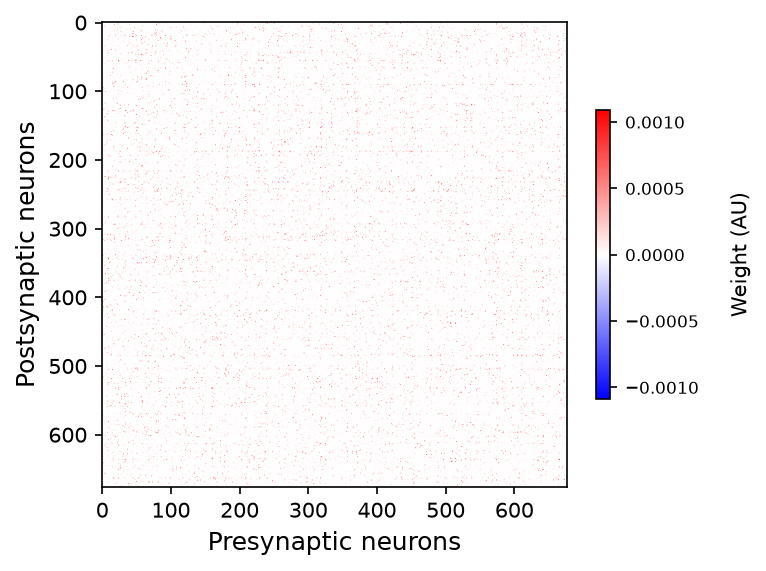

In [79]:
plot_matrix(syn_mat_l234)

In [80]:
# Connectivity parameters
g = .002  # overall gain of connectivity
connectivity_proba = .25 # Likelihood of two neurons to be connected with each other
r_inhibitory = .10 # Ratio of inhibitory neurons
inh_exc_balance = .15 # Result of I/E for every neuron's input

# Simulation parameters
t_max = 50 # Length of simulation
dt = 0.01 # Simulation time step
t_stimulus_start = 1 # Stimulus start time
t_stimulus_end = 15 # Stimulus end time
stim_strength = 10 # Stimulus strength rate
tau = .25 # Neuron time constant

# Simulation variables
n_steps = int(t_max / dt)

random_seed = 42

EE mean:  0.0014771048744460864
IE mean:  0.0016248153618906944
EI mean:  -0.0022
II mean:  -0.002


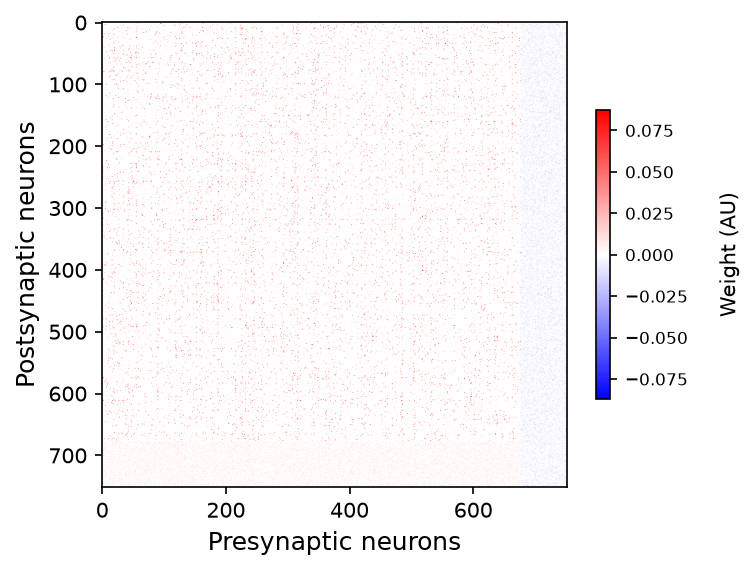

In [81]:
W = observed_plus_random_connectivity_matrix_random_inh(syn_mat_l234, r_inhibitory=r_inhibitory, g=500*g,
                                             connectivity_proba=connectivity_proba, random_seed=random_seed,
                                             inh_exc_balance=inh_exc_balance)
plot_matrix(W)

### plotting integral metric for this W

eps: 0.1006559359185726
done with first int


(array([635., 622., 356., 185., 122.,  50.,  12.,   9.,   7.,   2.]),
 array([0.13323   , 0.14122394, 0.14921787, 0.1572118 , 0.16520573,
        0.17319966, 0.18119359, 0.18918752, 0.19718146, 0.20517539,
        0.21316932]),
 <BarContainer object of 10 artists>)

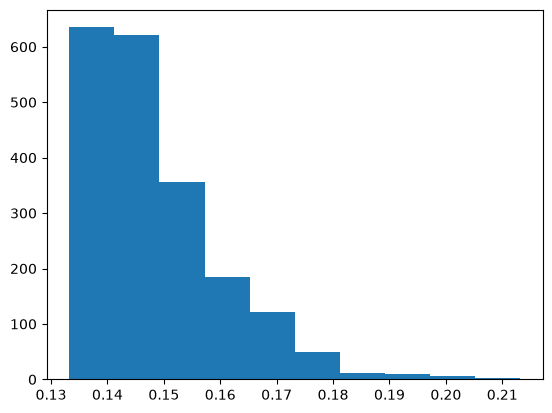

In [71]:
#random vectors
N = 2000

A = W - np.eye(len(W))
eAv_ints, vs = rand_v_ints(A,N)
plt.hist(eAv_ints)

eps: 0.1006559359185726
eps: 0.1006559359185726
0.9756440834892036


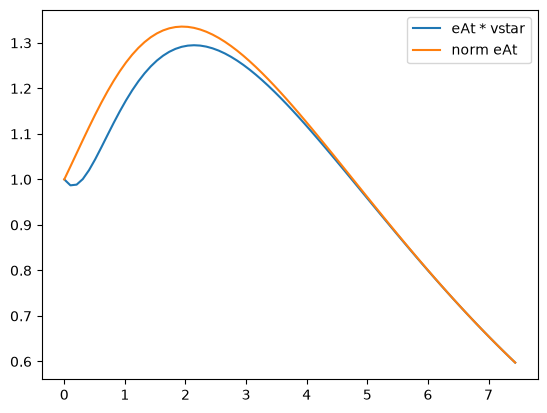

In [72]:
ts, eAint = calc_eAint(A)
eAs = [np.linalg.norm(expm(A*ts[i]),ord=2) for i in range(len(ts))]

v = calc_vstar(A)
eAvs = [np.linalg.norm(expm_multiply(A*ts[j], v),ord=2) for j in range(len(ts))]

print(calc_eAvint(A,v,ts)/eAint)

plt.plot(ts,eAvs,label='eAt * vstar')
plt.plot(ts,eAs,label='norm eAt')
plt.legend()

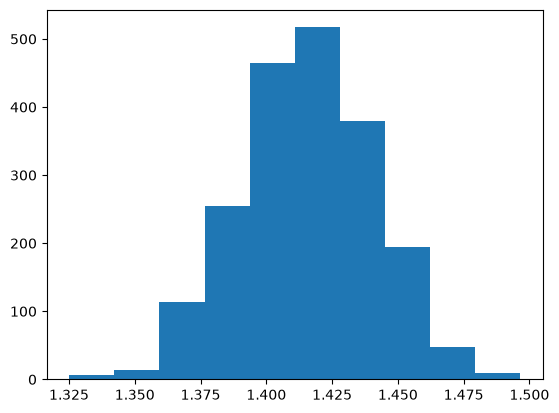

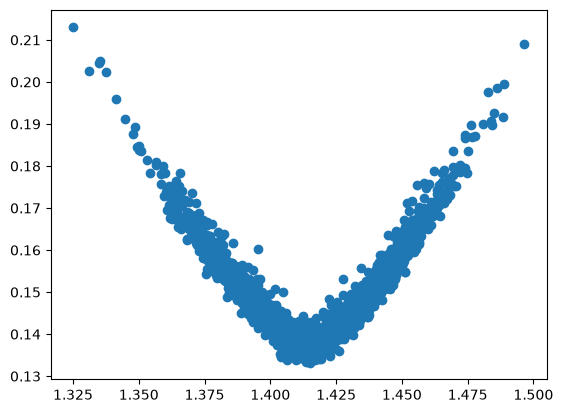

In [73]:
vdists = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
plt.hist(vdists)
plt.show()

plt.scatter(vdists, eAv_ints)
plt.show()

Restricting the distance from v star, because it seems like on average the vectors aren't very close to v star. 

In [22]:
#test N random vectors at a limited distance from vstar
def rand_v_ints_vstar(A,N,r=0.1):
    #N = number of random vectors v
    ts, eAint = calc_eAint(A)
    print("done with first int")

    vstar = calc_vstar(A)

    #N vectors of length matching A x 1
    eAv_ints = np.zeros((N,1))
    vs = []
    rats = []
    for i in range(N):
        perturbation = np.random.randn(len(A))
        perturbation = r*perturbation/np.linalg.norm(perturbation)
        v = vstar + perturbation
        v = v/np.linalg.norm(v,ord=2)
        vs.append(v)
        eAv_ints[i] = calc_eAvint(A,v,ts)/eAint
        rats.append(eAv_ints[i]/np.linalg.norm(v - vstar))

    return eAv_ints, vs, rats

eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751


(array([  4.,  22., 110., 308., 515., 532., 319., 141.,  39.,  10.]),
 array([0.99938994, 0.99939653, 0.99940312, 0.99940971, 0.9994163 ,
        0.99942289, 0.99942948, 0.99943607, 0.99944266, 0.99944925,
        0.99945584]),
 <BarContainer object of 10 artists>)

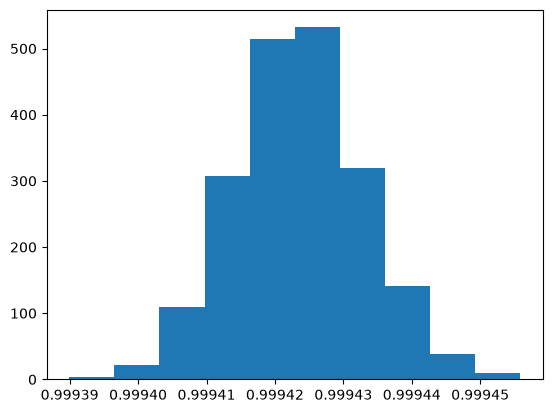

In [41]:
N = 2000

A = W - np.eye(len(W))
eAv_ints01, vs, rats = rand_v_ints_vstar(A,N,r=0.1)
plt.hist(eAv_ints01)

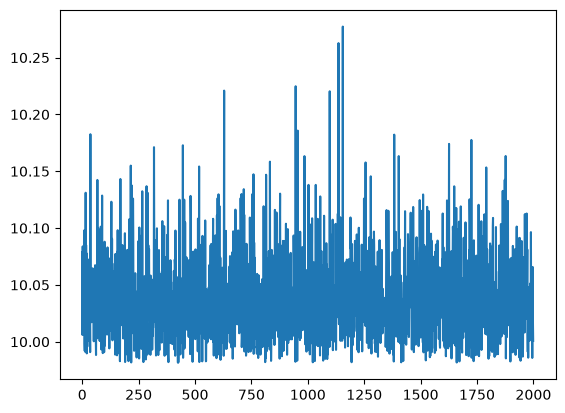

In [42]:
plt.plot(rats)

eps: 0.8750099970058751


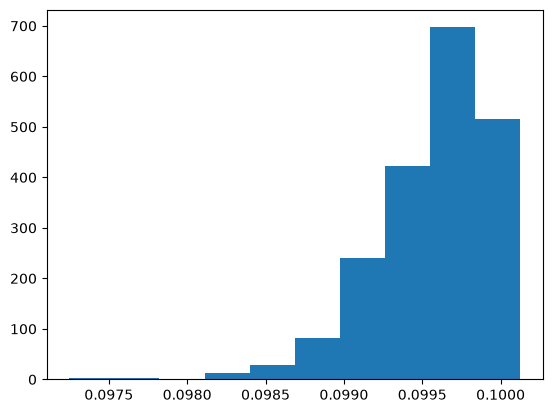

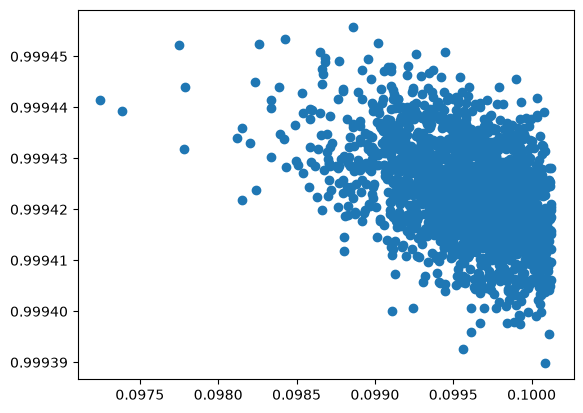

In [43]:
v = calc_vstar(A)
vdists01 = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
plt.hist(vdists01)
plt.show()

plt.scatter(vdists01, eAv_ints01)
plt.show()

r = 0.5

eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751


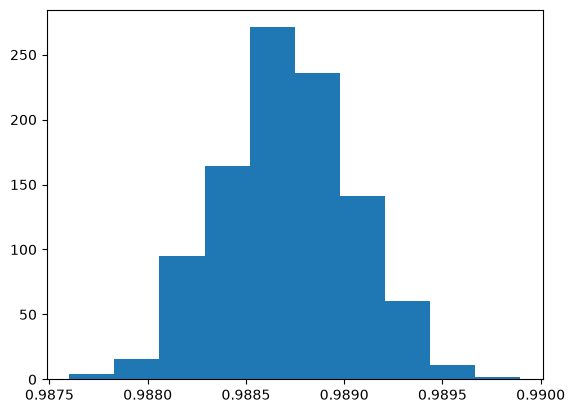

eps: 0.8750099970058751


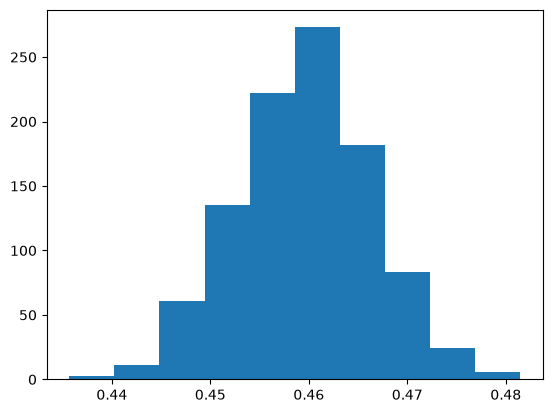

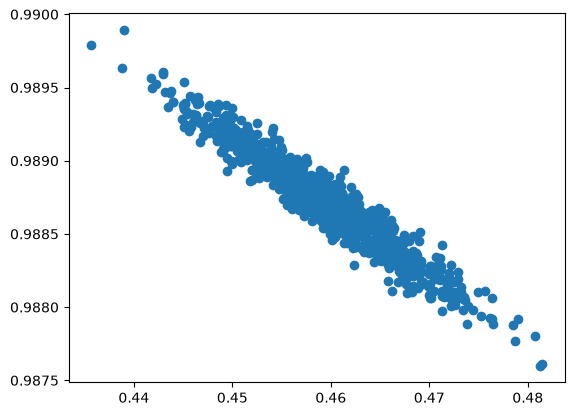

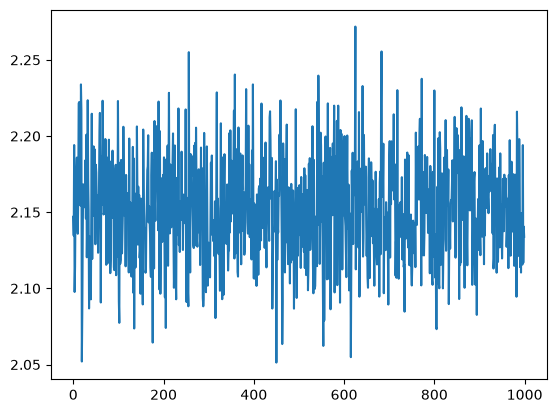

In [44]:
N = 1000

A = W - np.eye(len(W))
eAv_ints05, vs, rats = rand_v_ints_vstar(A,N,r=0.5)
plt.hist(eAv_ints05)
plt.show()

v = calc_vstar(A)
vdists05 = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
plt.hist(vdists05)
plt.show()

plt.scatter(vdists05, eAv_ints05)
plt.show()

plt.plot(rats)
plt.show()

r = 1

eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751


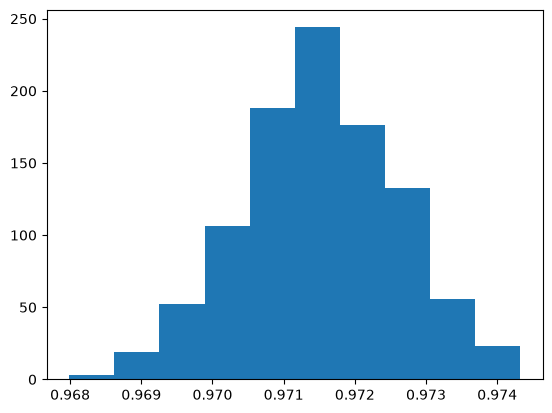

eps: 0.8750099970058751


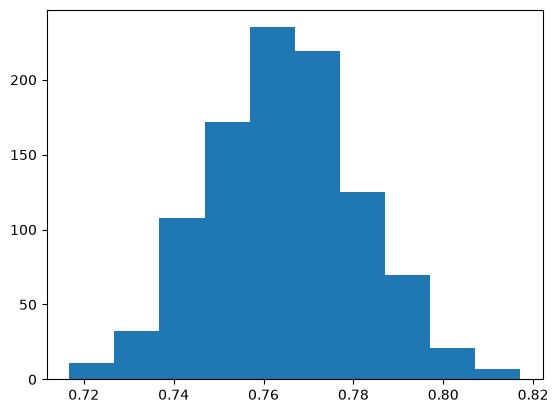

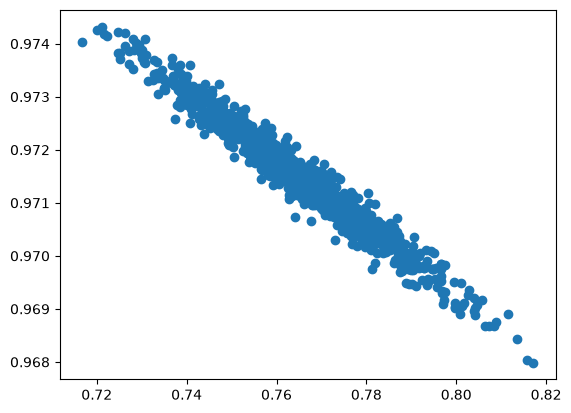

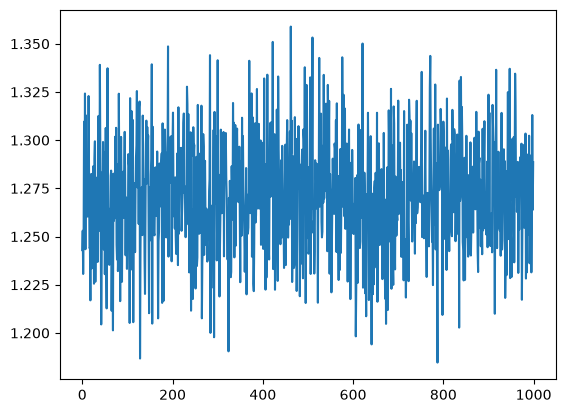

In [45]:
N = 1000

A = W - np.eye(len(W))
eAv_ints1, vs, rats = rand_v_ints_vstar(A,N,r=1)
plt.hist(eAv_ints1)
plt.show()

v = calc_vstar(A)
vdists1 = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
plt.hist(vdists1)
plt.show()

plt.scatter(vdists1, eAv_ints1)
plt.show()

plt.plot(rats)
plt.show()

r = 1.5 (trying to reach the threshold where there's no more correlation between vdist and eAvint)

eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751


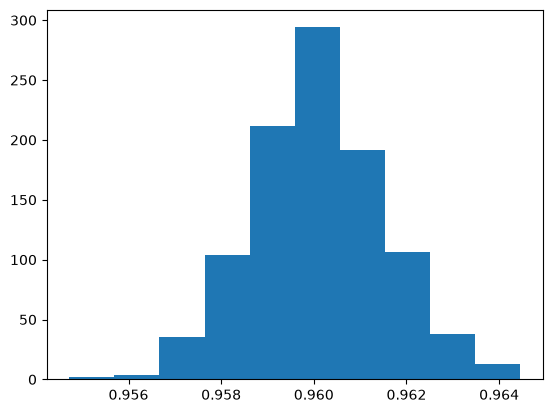

eps: 0.8750099970058751


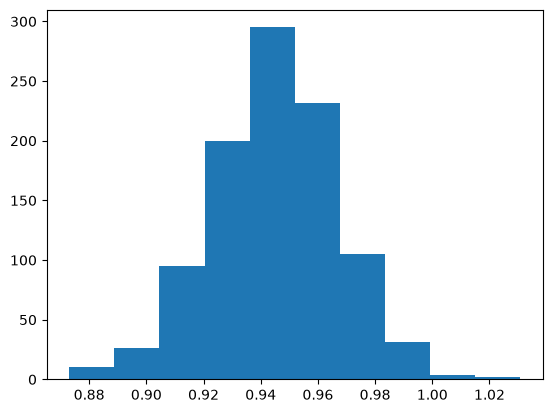

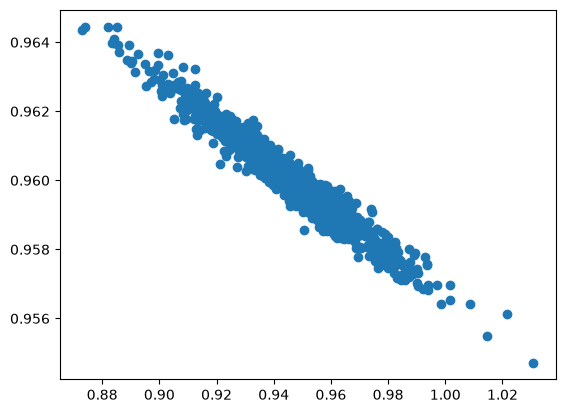

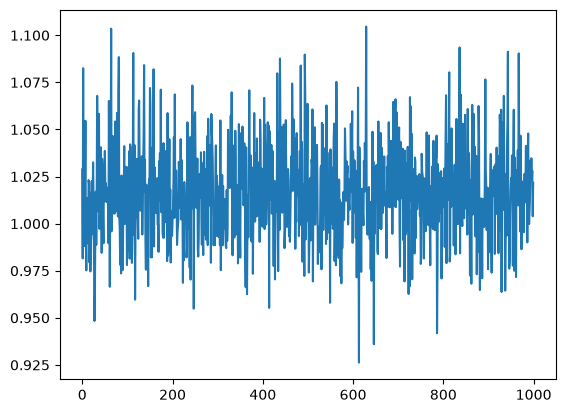

In [46]:
N = 1000

A = W - np.eye(len(W))
eAv_ints15, vs, rats = rand_v_ints_vstar(A,N,r=1.5)
plt.hist(eAv_ints15)
plt.show()

v = calc_vstar(A)
vdists15 = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
plt.hist(vdists15)
plt.show()

plt.scatter(vdists15, eAv_ints15)
plt.show()

plt.plot(rats)
plt.show()

r = 2

eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751


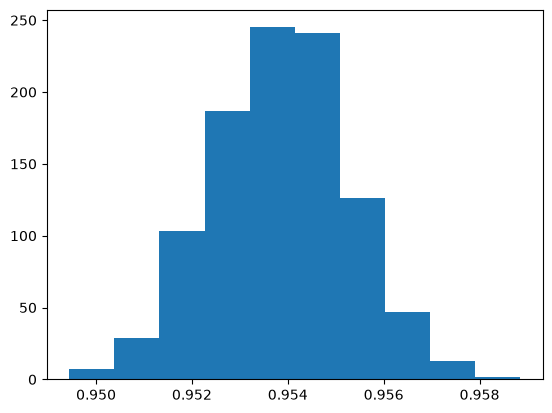

eps: 0.8750099970058751


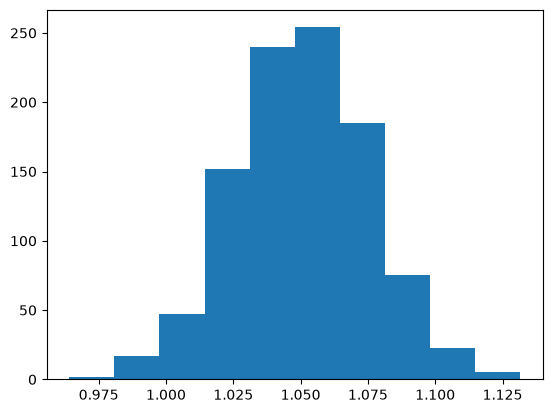

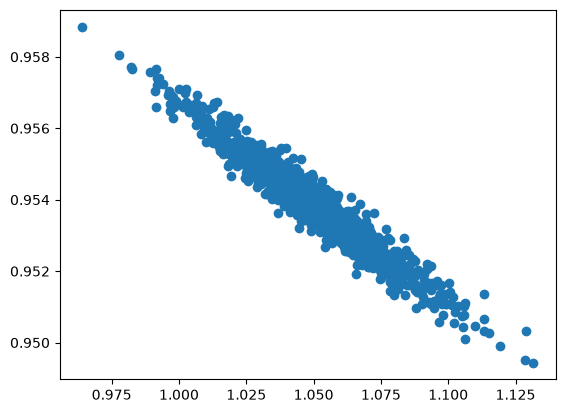

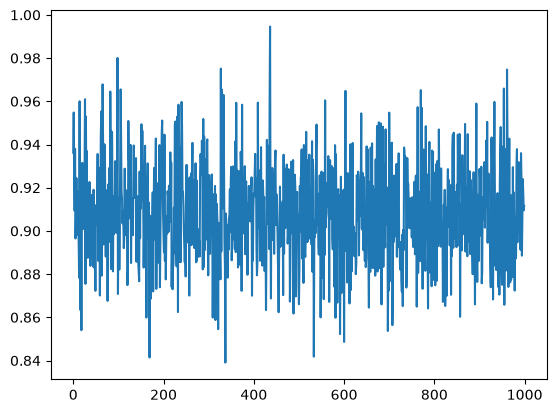

In [47]:
N = 1000

A = W - np.eye(len(W))
eAv_ints2, vs, rats = rand_v_ints_vstar(A,N,r=2)
plt.hist(eAv_ints2)
plt.show()

v = calc_vstar(A)
vdists2 = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
plt.hist(vdists2)
plt.show()

plt.scatter(vdists2, eAv_ints2)
plt.show()

plt.plot(rats)
plt.show()

r = 3

eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751


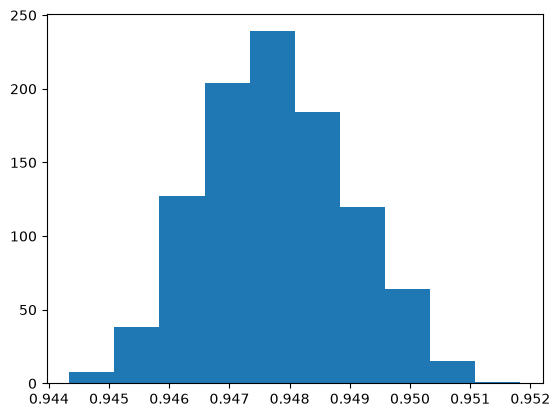

eps: 0.8750099970058751


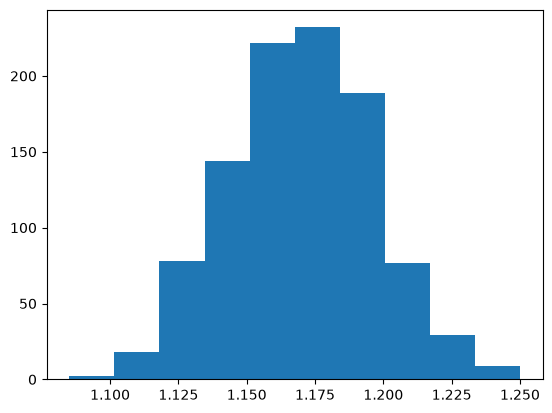

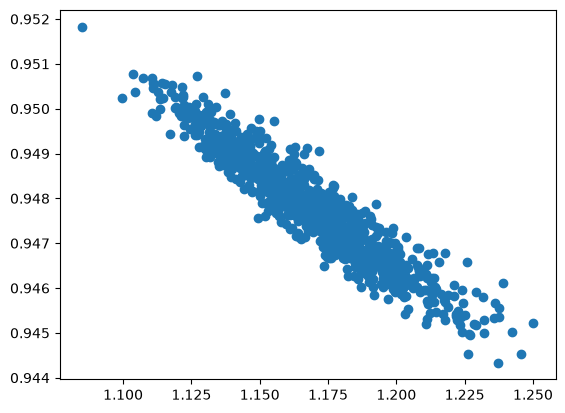

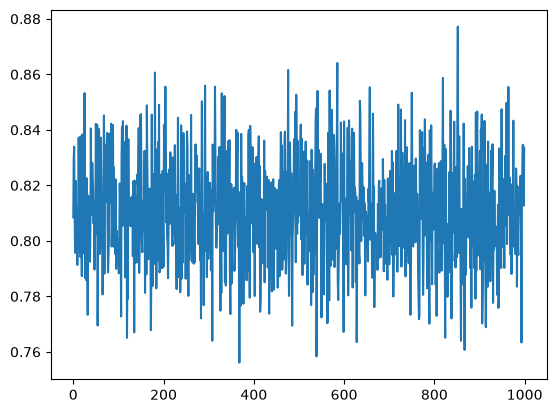

In [48]:
N = 1000

A = W - np.eye(len(W))
eAv_ints3, vs, rats = rand_v_ints_vstar(A,N,r=3)
plt.hist(eAv_ints3)
plt.show()

v = calc_vstar(A)
vdists3 = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
plt.hist(vdists3)
plt.show()

plt.scatter(vdists3, eAv_ints3)
plt.show()

plt.plot(rats)
plt.show()

r = 4

eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751


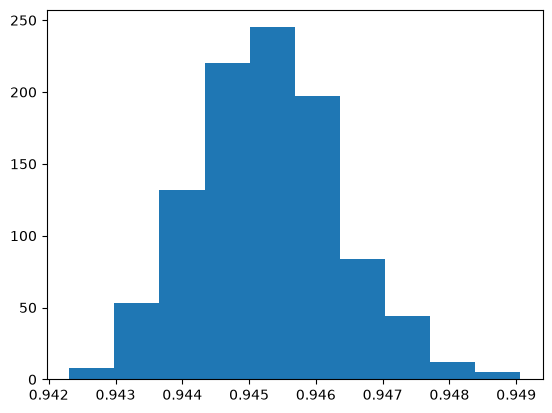

eps: 0.8750099970058751


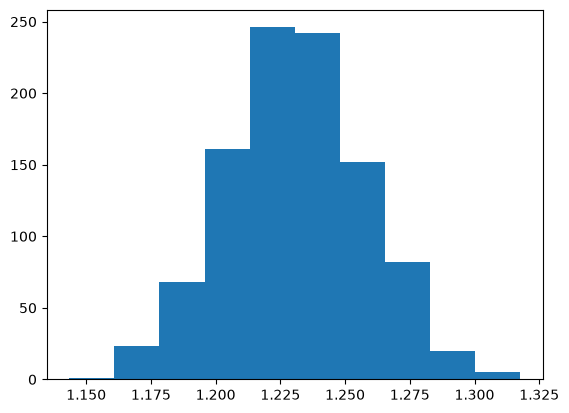

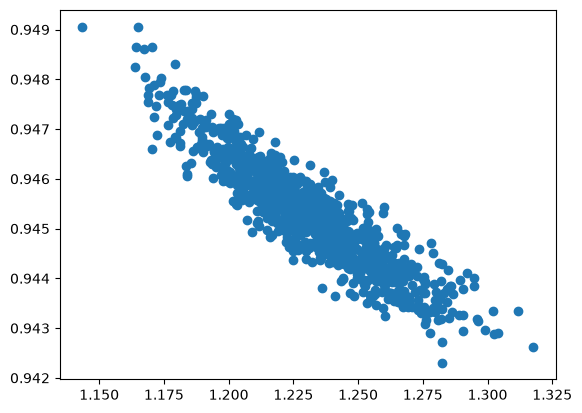

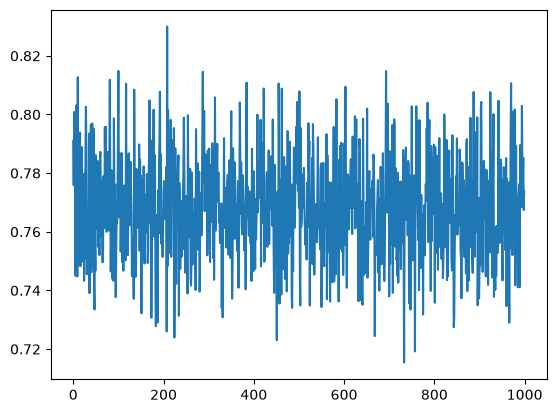

In [49]:
N = 1000

A = W - np.eye(len(W))
eAv_ints4, vs, rats = rand_v_ints_vstar(A,N,r=4)
plt.hist(eAv_ints4)
plt.show()

v = calc_vstar(A)
vdists4 = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
plt.hist(vdists4)
plt.show()

plt.scatter(vdists4, eAv_ints4)
plt.show()

plt.plot(rats)
plt.show()

eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751


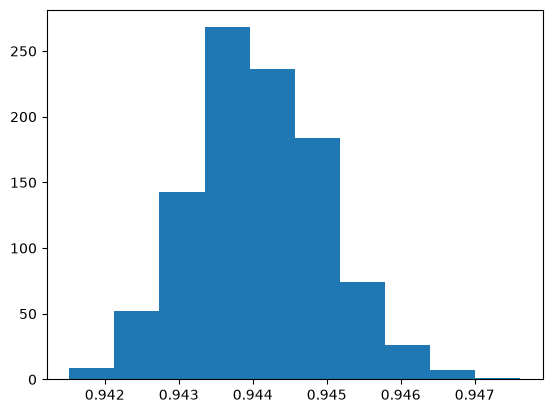

eps: 0.8750099970058751


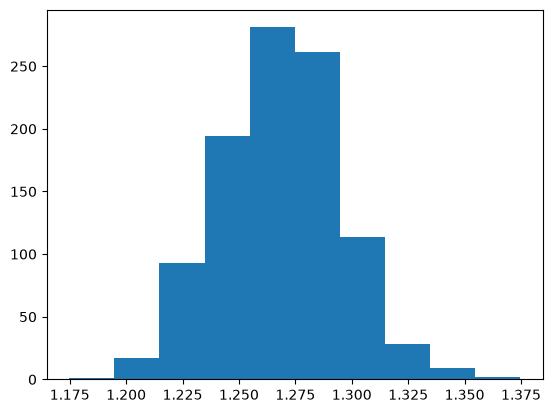

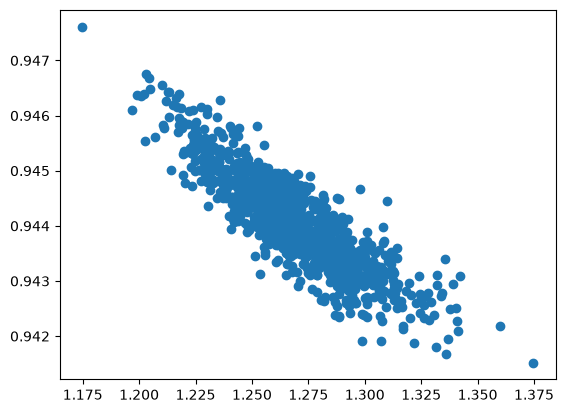

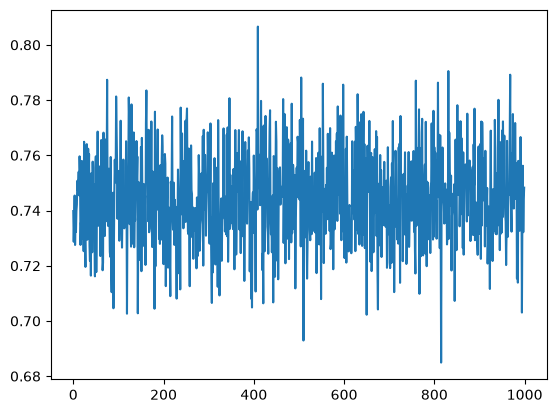

In [50]:
N = 1000

A = W - np.eye(len(W))
eAv_ints5, vs, rats = rand_v_ints_vstar(A,N,r=5)
plt.hist(eAv_ints5)
plt.show()

v = calc_vstar(A)
vdists5 = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
plt.hist(vdists5)
plt.show()

plt.scatter(vdists5, eAv_ints5)
plt.show()

plt.plot(rats)
plt.show()

### Doing this systematically

In [51]:
np.array([np.linspace(0.1,2,20)]).flatten()

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3,
       1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. ])

eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps:

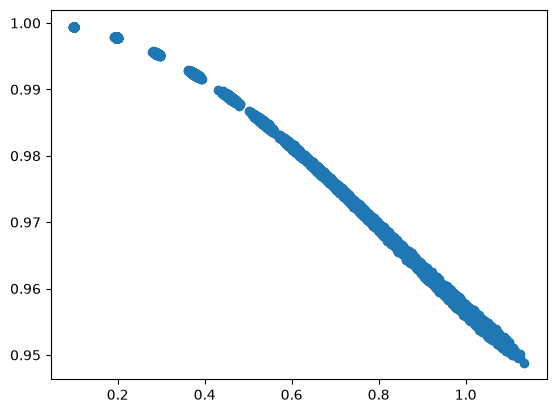

eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751


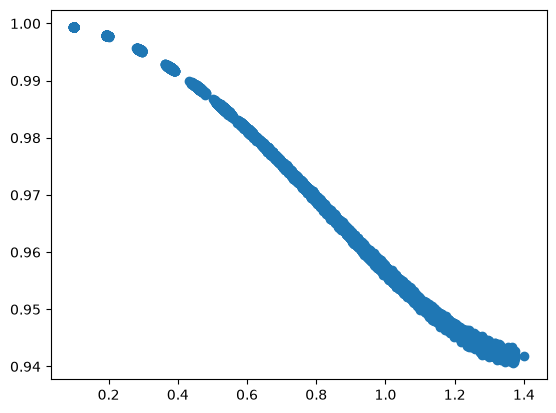

In [52]:
A = W - np.eye(len(W))
vdists = []
eAv_ints = []
for r in np.linspace(0.1,2,20):
    N = 1000

    eAv_ints_r, vs, rats = rand_v_ints_vstar(A,N,r=r)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

for r in np.linspace(2.5,7,10):
    N = 1000

    eAv_ints_r, vs, rats = rand_v_ints_vstar(A,N,r=r)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

Filling in/going further

eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751


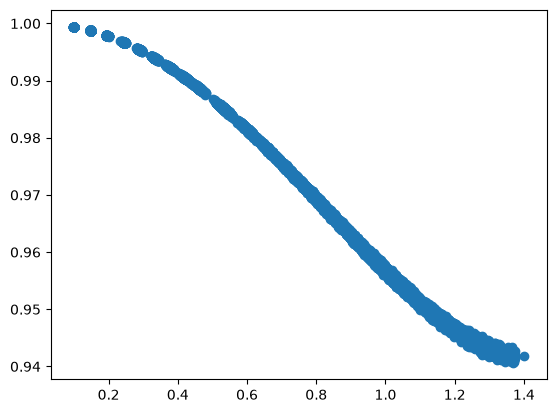

eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751


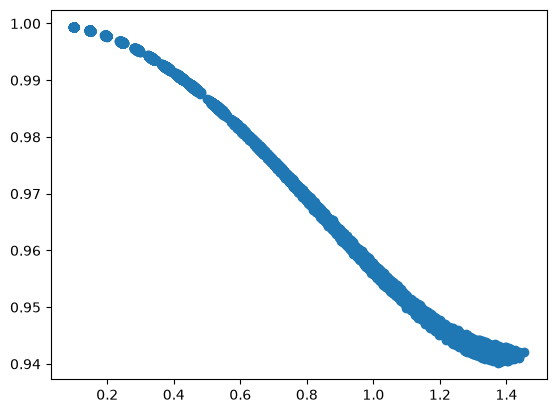

In [53]:
for r in np.linspace(0.15,.45,4):
    N = 1000

    eAv_ints_r, vs, rats = rand_v_ints_vstar(A,N,r=r)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

for r in np.linspace(7.5,14.5,8):
    N = 1000

    eAv_ints_r, vs, rats = rand_v_ints_vstar(A,N,r=r)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751


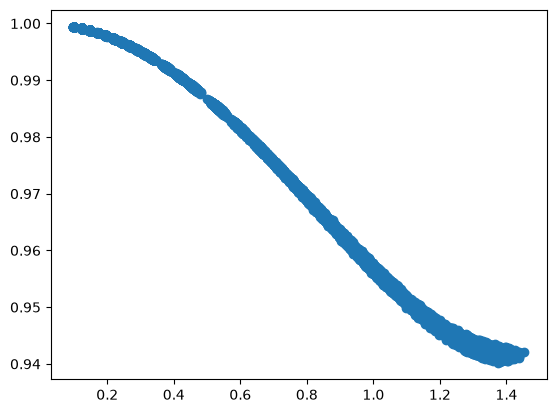

eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751


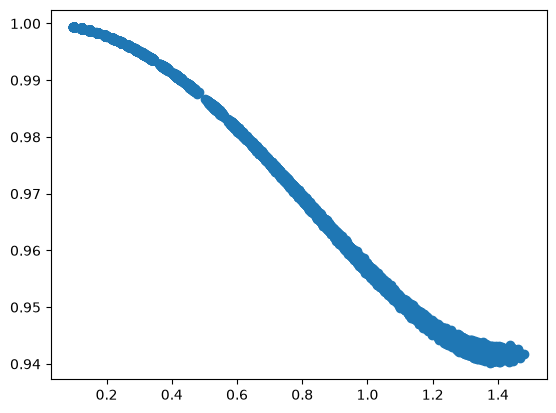

In [54]:
for r in np.linspace(0.125,.325,5):
    N = 1000

    eAv_ints_r, vs, rats = rand_v_ints_vstar(A,N,r=r)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

for r in np.linspace(15,35,5):
    N = 1000

    eAv_ints_r, vs, rats = rand_v_ints_vstar(A,N,r=r)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

In [23]:
def rand_v_ints_neg_vstar(A,N,r=0.1):
    #N = number of random vectors v
    ts, eAint = calc_eAint(A)
    print("done with first int")

    vstar = -1*calc_vstar(A)

    #N vectors of length matching A x 1
    eAv_ints = np.zeros((N,1))
    vs = []

    for i in range(N):
        perturbation = np.random.randn(len(A))
        perturbation = r*perturbation/np.linalg.norm(perturbation)
        v = vstar + perturbation
        v = v/np.linalg.norm(v,ord=2)
        vs.append(v)
        eAv_ints[i] = calc_eAvint(A,v,ts)/eAint

    return eAv_ints, vs

eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751


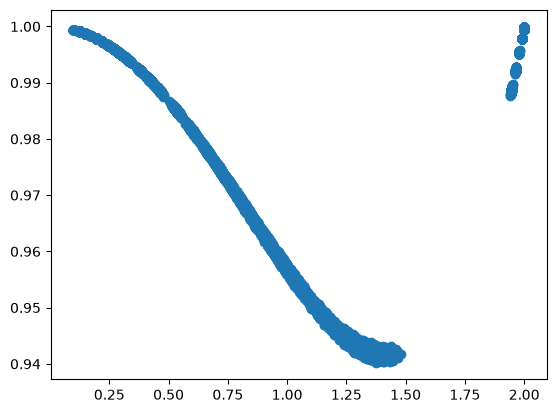

In [56]:
for r in np.linspace(0,.5,6):
    N = 1000

    eAv_ints_r, vs = rand_v_ints_neg_vstar(A,N,r=r)
    v = calc_vstar(A)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.87500

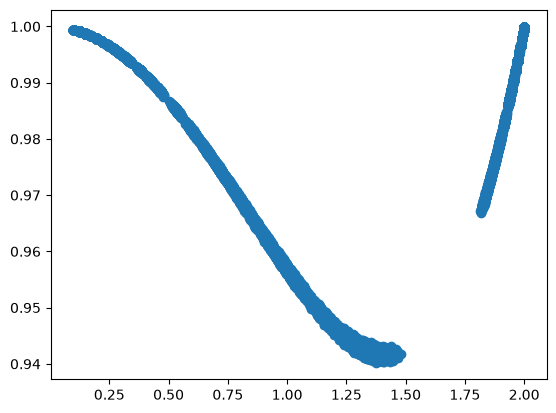

In [57]:
for r in np.linspace(0.05,1.05,11):
    N = 1000

    eAv_ints_r, vs = rand_v_ints_neg_vstar(A,N,r=r)
    v = calc_vstar(A)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751
eps: 0.8750099970058751
done with first int
eps: 0.8750099970058751
eps: 0.8750099970058751


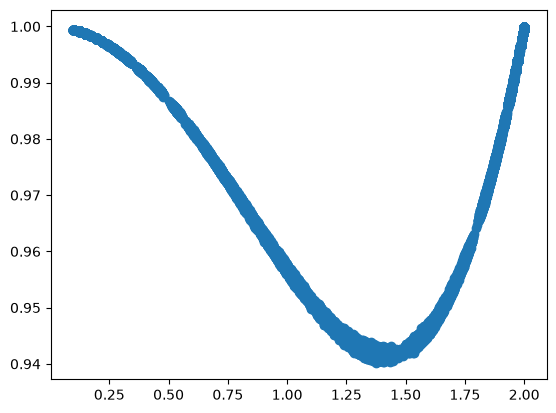

In [58]:
for r in np.linspace(1.1,5.1,9):
    N = 1000

    eAv_ints_r, vs = rand_v_ints_neg_vstar(A,N,r=r)
    v = calc_vstar(A)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

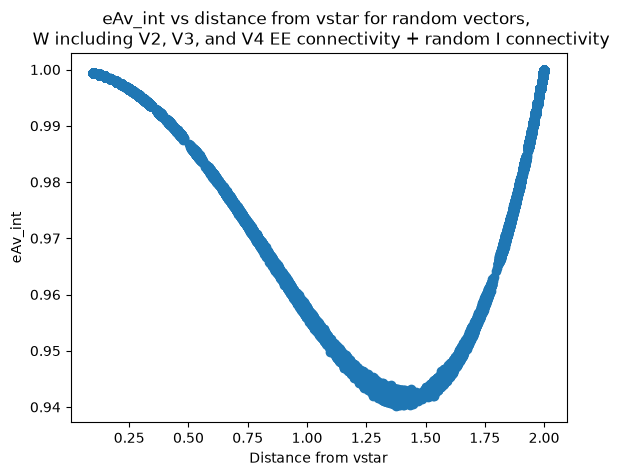

In [59]:
plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.xlabel("Distance from vstar")
plt.ylabel("eAv_int")
plt.title("eAv_int vs distance from vstar for random vectors, \n W including V2, V3, and V4 EE connectivity + random I connectivity")
plt.show()

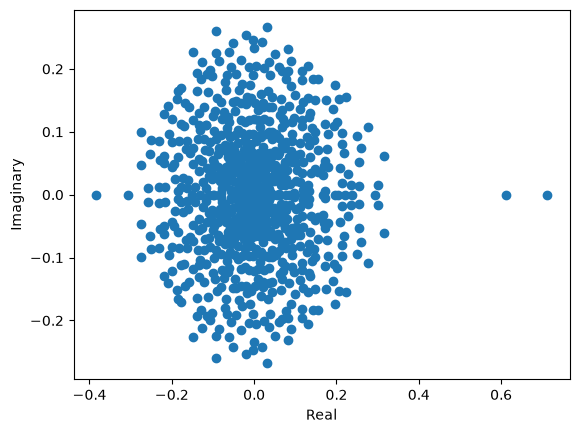

In [82]:
from numpy import linalg as LA
eigenvalues, eigenvectors = LA.eig(W)
x = [ele.real for ele in eigenvalues]
# extract imaginary part
y = [ele.imag for ele in eigenvalues]

# plot the complex numbers
plt.scatter(x, y)
plt.ylabel('Imaginary')
plt.xlabel('Real')
plt.show()

In [83]:
#condition number of eigenvector matrix
cond = np.linalg.cond(eigenvectors)
print("Condition number of eigenvector matrix:", cond)

Condition number of eigenvector matrix: 2997.884686932279


## Same thing with erdos reyni weight matrix with same average strength of connection

EE mean:  0.0014792899408284017
IE mean:  0.0016272189349112428
EI mean:  -0.0021710526315789473
II mean:  -0.0019736842105263154
EE mean:  0.0014792899408284023
IE mean:  0.0016272189349112428
EI mean:  -0.0021710526315789477
II mean:  -0.0019736842105263154


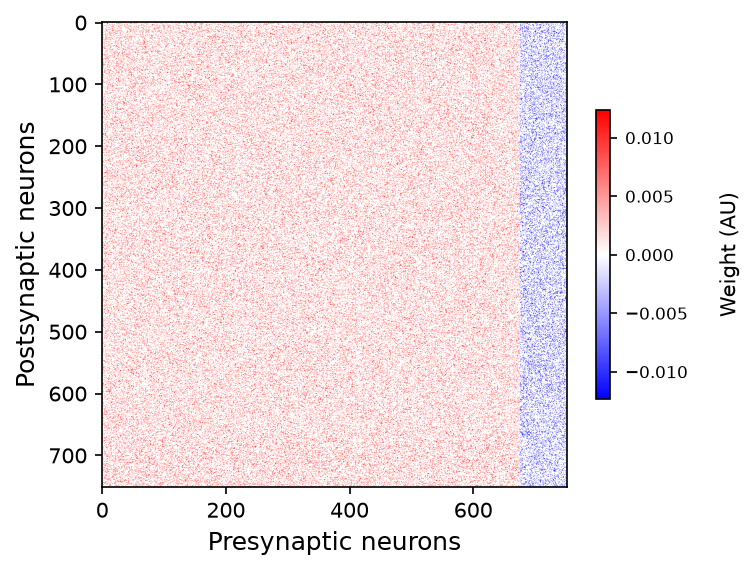

In [85]:
dims = W.shape
rng = np.random.default_rng()
random_seed = int(rng.integers(0, 1000000))
W_er = generate_random_connectivity_matrix(n_neurons = dims[0], r_inhibitory=r_inhibitory, g=500*g, 
                                             connectivity_proba=connectivity_proba, random_seed=random_seed, 
                                             balance_W=True, inh_exc_balance=inh_exc_balance)

W_er_unif = generate_random_connectivity_matrix_unif(n_neurons = dims[0], r_inhibitory=r_inhibitory, g=500*g, 
                                             connectivity_proba=connectivity_proba, random_seed=random_seed, 
                                             balance_W=True, inh_exc_balance=inh_exc_balance)

plot_matrix(W_er)

In [86]:
#check

JEE = np.mean(np.sum(W[:len(syn_mat_l234), :len(syn_mat_l234)], axis=1))
JEI = np.mean(np.sum(W[:len(syn_mat_l234), len(syn_mat_l234):], axis=1))
JIE = np.mean(np.sum(W[len(syn_mat_l234):, :len(syn_mat_l234)], axis=1))
JII = np.mean(np.sum(W[len(syn_mat_l234):, len(syn_mat_l234):], axis=1))
print(JEE)
print(JEI)
print(JIE)
print(JII)

JEE = np.mean(np.sum(W_er[:len(syn_mat_l234), :len(syn_mat_l234)], axis=1))
JEI = np.mean(np.sum(W_er[:len(syn_mat_l234), len(syn_mat_l234):], axis=1))
JIE = np.mean(np.sum(W_er[len(syn_mat_l234):, :len(syn_mat_l234)], axis=1))
JII = np.mean(np.sum(W_er[len(syn_mat_l234):, len(syn_mat_l234):], axis=1))
print(JEE)
print(JEI)
print(JIE)
print(JII)

1.0
-0.16499999999999998
1.1
-0.15
0.9978075749032868
-0.16262513592515357
1.0974790518592028
-0.14759253436848488


eps: 0.13891938081801278
done with first int


(array([900., 507., 295., 149.,  76.,  47.,  17.,   5.,   3.,   1.]),
 array([0.18915083, 0.19653836, 0.20392589, 0.21131343, 0.21870096,
        0.22608849, 0.23347602, 0.24086355, 0.24825109, 0.25563862,
        0.26302615]),
 <BarContainer object of 10 artists>)

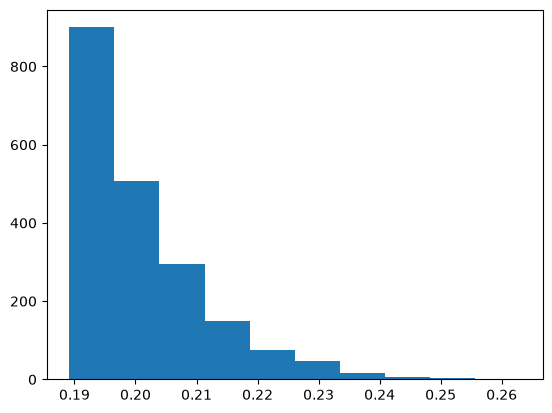

In [87]:
#random vectors
N = 2000

A_er = W_er - np.eye(len(W_er))
eAv_ints, vs = rand_v_ints(A_er,N)
plt.hist(eAv_ints)

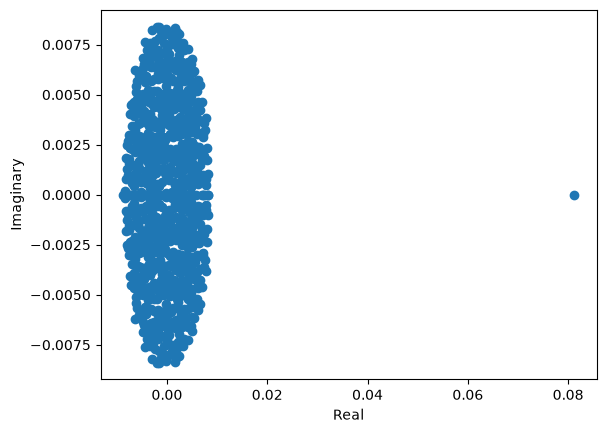

Condition number of eigenvector matrix: 808.293647518798


In [46]:
from numpy import linalg as LA
eigenvalues, eigenvectors = LA.eig(W_er)
x = [ele.real for ele in eigenvalues]
# extract imaginary part
y = [ele.imag for ele in eigenvalues]

# plot the complex numbers
plt.scatter(x, y)
plt.ylabel('Imaginary')
plt.xlabel('Real')
plt.show()

#condition number of eigenvector matrix
cond = np.linalg.cond(eigenvectors)
print("Condition number of eigenvector matrix:", cond)

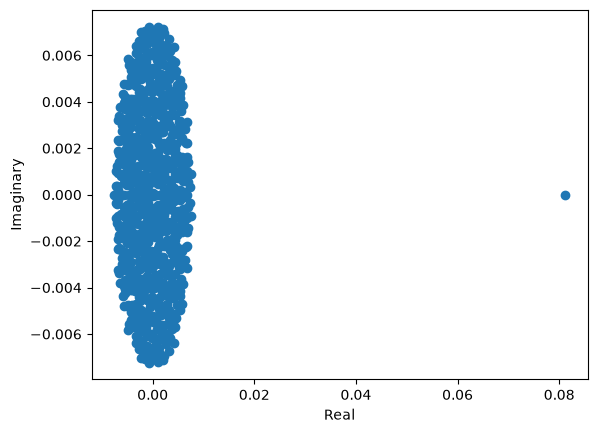

Condition number of eigenvector matrix: 633.7914010986384


In [66]:
from numpy import linalg as LA
eigenvalues, eigenvectors = LA.eig(W_er_unif)
x = [ele.real for ele in eigenvalues]
# extract imaginary part
y = [ele.imag for ele in eigenvalues]

# plot the complex numbers
plt.scatter(x, y)
plt.ylabel('Imaginary')
plt.xlabel('Real')
plt.show()

#condition number of eigenvector matrix
cond = np.linalg.cond(eigenvectors)
print("Condition number of eigenvector matrix:", cond)

### plotting integral metric for ER weight graph

eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441


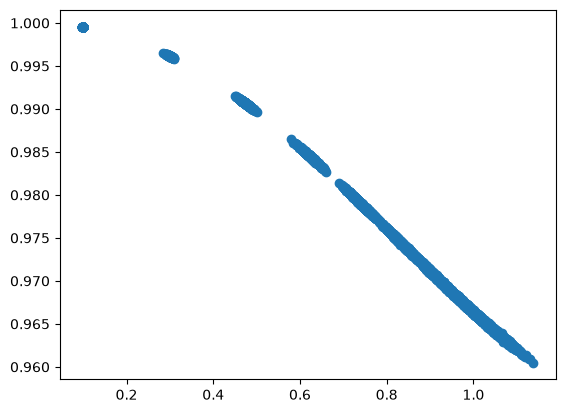

eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.90033

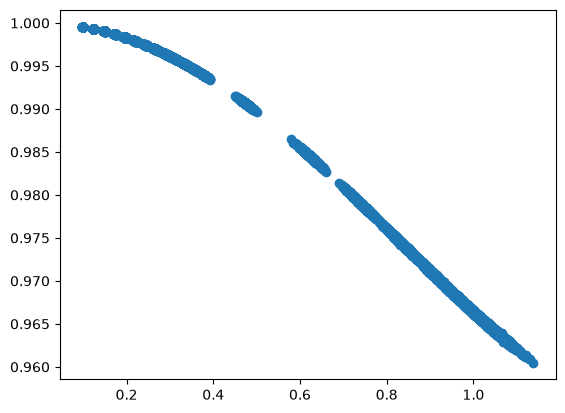

eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441


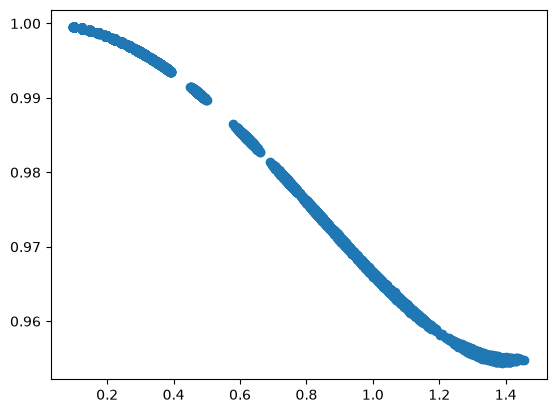

In [66]:
A_er = W_er - np.eye(len(W_er))
vdists = []
eAv_ints = []
for r in np.linspace(0.1,2,10):
    N = 1000

    eAv_ints_r, vs, rats = rand_v_ints_vstar(A_er,N,r=r)
    v = calc_vstar(A_er)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

for r in np.linspace(0.125,.4,12):
    N = 1000

    eAv_ints_r, vs, rats = rand_v_ints_vstar(A_er,N,r=r)
    v = calc_vstar(A_er)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

for r in np.linspace(2.5,15,4):
    N = 1000

    eAv_ints_r, vs, rats = rand_v_ints_vstar(A_er,N,r=r)
    v = calc_vstar(A_er)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441


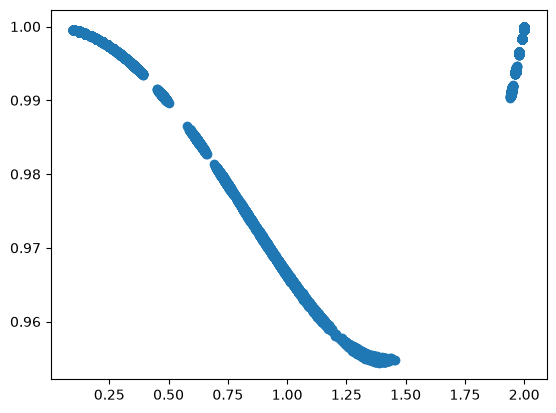

eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.90033

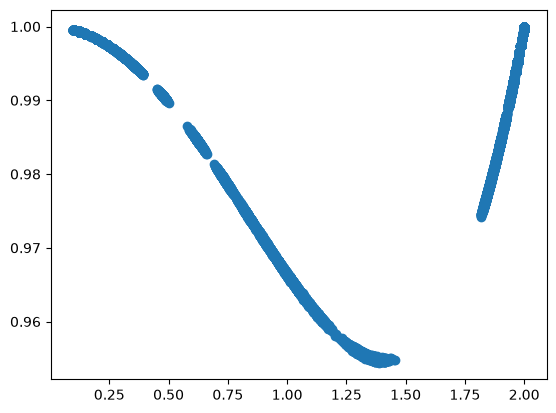

eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441


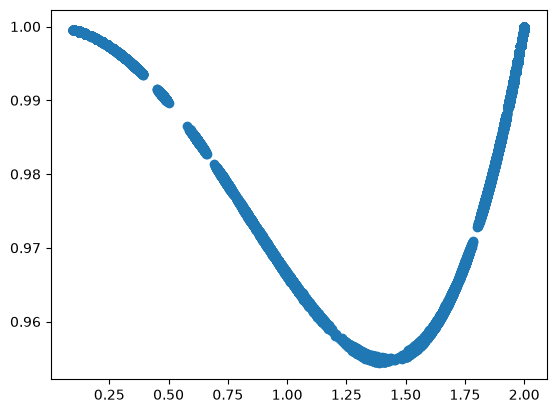

In [67]:
for r in np.linspace(0,.5,6):
    N = 1000

    eAv_ints_r, vs = rand_v_ints_neg_vstar(A_er,N,r=r)
    v = calc_vstar(A_er)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

for r in np.linspace(0.05,1.05,11):
    N = 1000

    eAv_ints_r, vs = rand_v_ints_neg_vstar(A_er,N,r=r)
    v = calc_vstar(A_er)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

for r in np.linspace(1.1,5.1,9):
    N = 1000

    eAv_ints_r, vs = rand_v_ints_neg_vstar(A_er,N,r=r)
    v = calc_vstar(A_er)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441


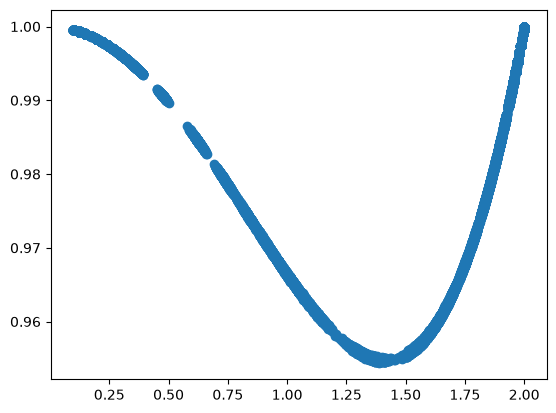

In [68]:
for r in np.linspace(1.35,1.35,1):
    N = 1000

    eAv_ints_r, vs = rand_v_ints_neg_vstar(A_er,N,r=r)
    v = calc_vstar(A_er)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441


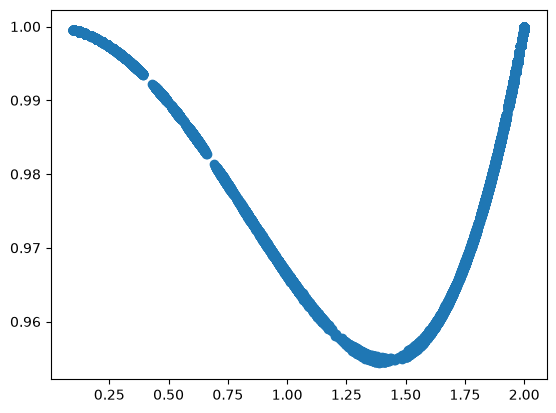

In [69]:
for r in np.linspace(0.4,.7,4):
    N = 1000

    eAv_ints_r, vs, rats = rand_v_ints_vstar(A_er,N,r=r)
    v = calc_vstar(A_er)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441
eps: 0.9003301667540441
done with first int
eps: 0.9003301667540441
eps: 0.9003301667540441


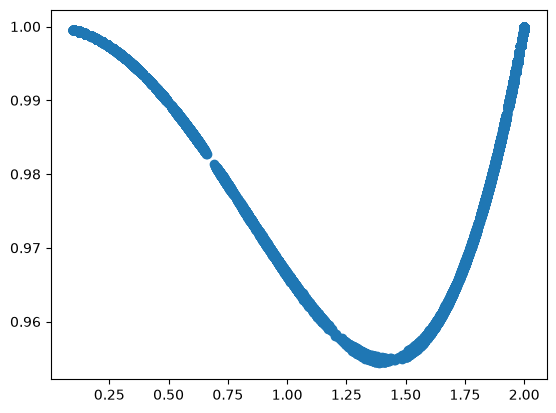

In [70]:
for r in np.linspace(0.45,.65,2):
    N = 1000

    eAv_ints_r, vs, rats = rand_v_ints_vstar(A_er,N,r=r)
    v = calc_vstar(A_er)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

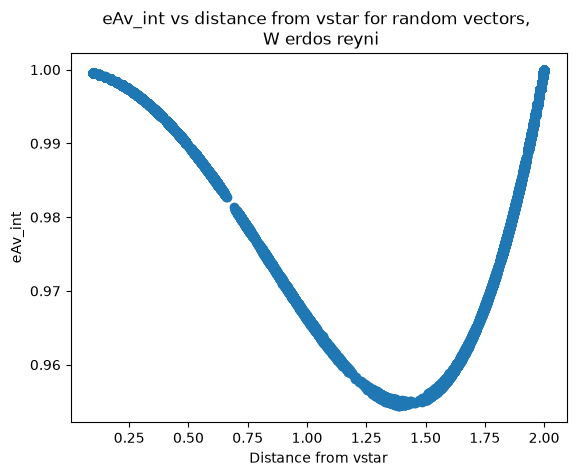

: 

In [ ]:
plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.xlabel("Distance from vstar")
plt.ylabel("eAv_int")
plt.title("eAv_int vs distance from vstar for random vectors, \n W erdos reyni")
plt.show()

## Separating out layers

In [14]:
L234_syn

,id,pre_pt_position_x,pre_pt_position_y,pre_pt_position_z,post_pt_position_x,post_pt_position_y,post_pt_position_z,pre_pt_root_id,post_pt_root_id,size,size_nm3,pre_cell_type,post_cell_type
0,159216448,176448,106294,20943,176436,106342,20932,864691135102381856,864691136138779517,0.078086,78086320.0,L3IT,L2IT
1,161941440,176674,167378,22841,176718,167326,22848,864691134966025503,864691135274830353,0.049845,49844528.0,L4IT,L4IT
2,143074676,167994,141086,20860,168092,141128,20857,864691135102274592,864691135398925345,0.028841,28840612.0,L3IT,L3IT
3,151613544,174292,148800,22264,174198,148954,22269,864691134966710559,864691135988557315,0.186401,186401296.0,L4IT,L4IT
4,156764818,175866,101456,21549,175948,101418,21553,864691134941412707,864691135274860561,0.065441,65441004.0,L3IT,L4IT
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16268,170910871,184758,101264,23203,184692,101296,23206,864691136968585678,864691135572576237,0.188842,188841712.0,L2IT,L2IT
16269,176191173,184416,184272,21571,184388,184292,21575,864691137056393846,864691135060882843,0.192641,192640928.0,L3IT,L4IT
16270,208966528,204928,110076,22647,204930,110178,22656,864691136968773070,864691135409940425,0.068961,68960728.0,L4IT,L3IT
16271,158185689,176586,143684,22137,176526,143800,22143,864691136968529870,864691135503287618,0.065760,65760320.0,L3IT,L3IT


In [15]:
#isolating each layer
pre_ids_L2 = np.array(L234_syn[np.array(L234_syn["pre_cell_type"] == "L2IT") & np.array(L234_syn["post_cell_type"] == "L2IT")]["pre_pt_root_id"])
post_ids_L2 = np.array(L234_syn[np.array(L234_syn["pre_cell_type"] == "L2IT") & np.array(L234_syn["post_cell_type"] == "L2IT")]["post_pt_root_id"])
syn_df_l2 = filter_synapse_table(L234_syn, pre_ids_L2, post_ids_L2)

# Transform table to a matrix - synapses within a connection are summed
syn_mat_df_l2 = syn_df_l2.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                        values="size", aggfunc=lambda x: np.sum(x)).fillna(0)

# Make square matrix
input_output_ids = syn_mat_df_l2.index[np.isin(syn_mat_df_l2.index, syn_mat_df_l2.columns)]
syn_mat_l2 = np.array(syn_mat_df_l2.reindex(input_output_ids).reindex(columns=input_output_ids)) / 300

#L3
pre_ids_L3 = np.array(L234_syn[np.array(L234_syn["pre_cell_type"] == "L3IT") & np.array(L234_syn["post_cell_type"] == "L3IT")]["pre_pt_root_id"])
post_ids_L3 = np.array(L234_syn[np.array(L234_syn["pre_cell_type"] == "L3IT") & np.array(L234_syn["post_cell_type"] == "L3IT")]["post_pt_root_id"])
syn_df_l3 = filter_synapse_table(L234_syn, pre_ids_L3, post_ids_L3)

# Transform table to a matrix - synapses within a connection are summed
syn_mat_df_l3 = syn_df_l3.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                        values="size", aggfunc=lambda x: np.sum(x)).fillna(0)

# Make square matrix
input_output_ids = syn_mat_df_l3.index[np.isin(syn_mat_df_l3.index, syn_mat_df_l3.columns)]
syn_mat_l3 = np.array(syn_mat_df_l3.reindex(input_output_ids).reindex(columns=input_output_ids)) / 300


#L4
pre_ids_L4 = np.array(L234_syn[np.array(L234_syn["pre_cell_type"] == "L4IT") & np.array(L234_syn["post_cell_type"] == "L4IT")]["pre_pt_root_id"])
post_ids_L4 = np.array(L234_syn[np.array(L234_syn["pre_cell_type"] == "L4IT") & np.array(L234_syn["post_cell_type"] == "L4IT")]["post_pt_root_id"])
syn_df_l4 = filter_synapse_table(L234_syn, pre_ids_L4, post_ids_L4)

# Transform table to a matrix - synapses within a connection are summed
syn_mat_df_l4 = syn_df_l4.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                        values="size", aggfunc=lambda x: np.sum(x)).fillna(0)

# Make square matrix
input_output_ids = syn_mat_df_l4.index[np.isin(syn_mat_df_l4.index, syn_mat_df_l4.columns)]
syn_mat_l4 = np.array(syn_mat_df_l4.reindex(input_output_ids).reindex(columns=input_output_ids)) / 300


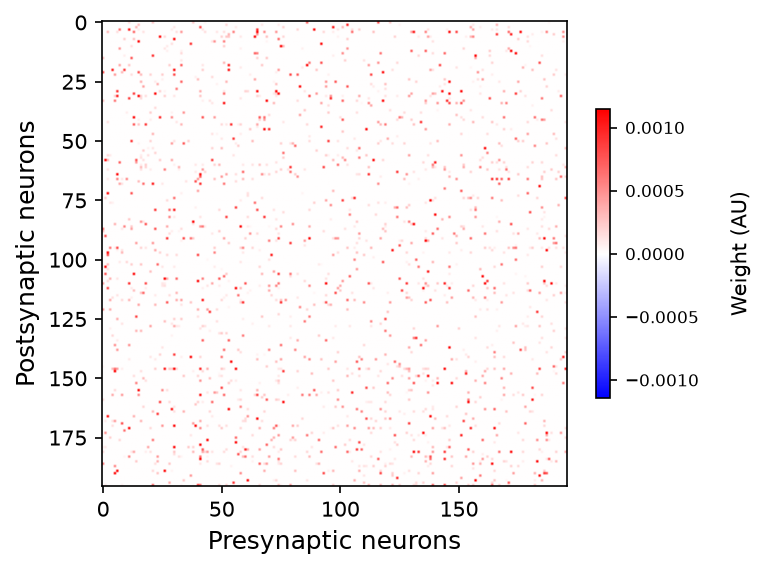

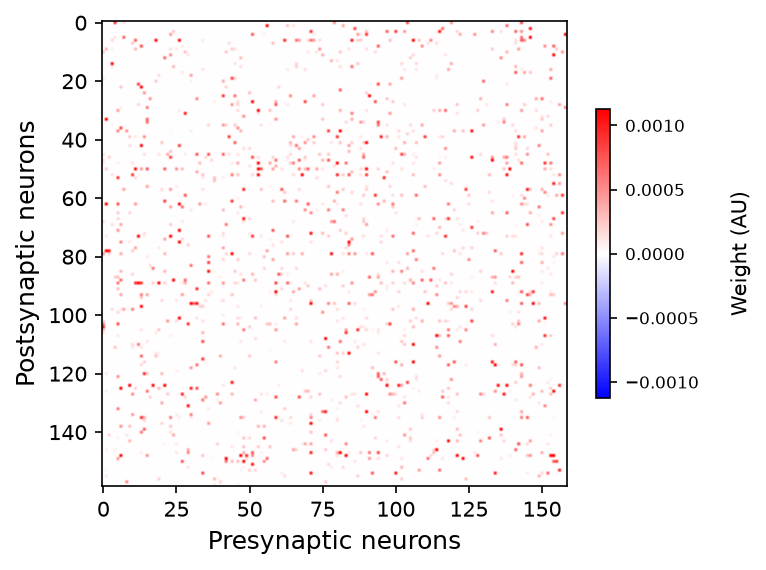

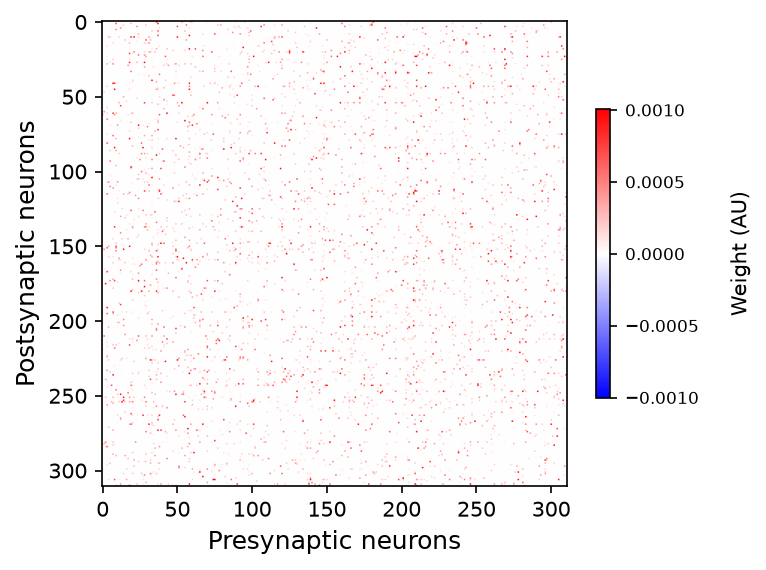

In [16]:
plot_matrix(syn_mat_l2)

plot_matrix(syn_mat_l3)

plot_matrix(syn_mat_l4) 

EE mean:  0.0005102040816326531
IE mean:  0.0005612244897959184
EI mean:  -0.0007857142857142857
II mean:  -0.0007142857142857144


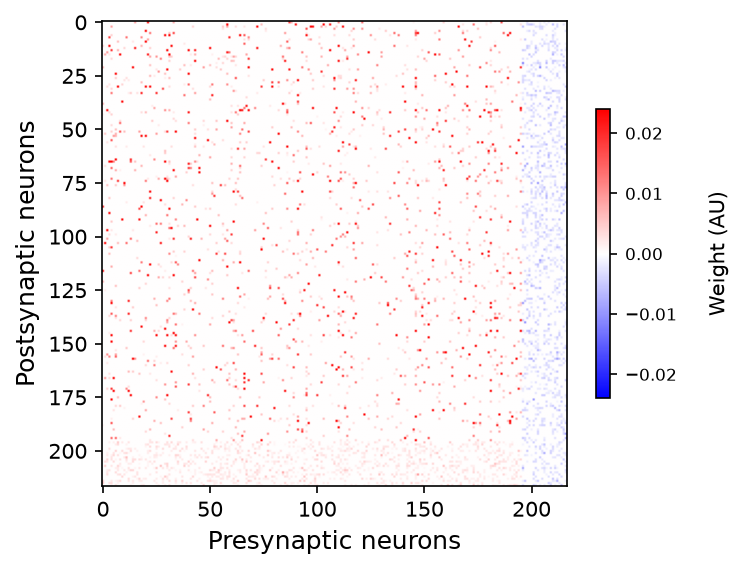

EE mean:  0.0006289308176100629
IE mean:  0.0006918238993710693
EI mean:  -0.0009705882352941179
II mean:  -0.0008823529411764706


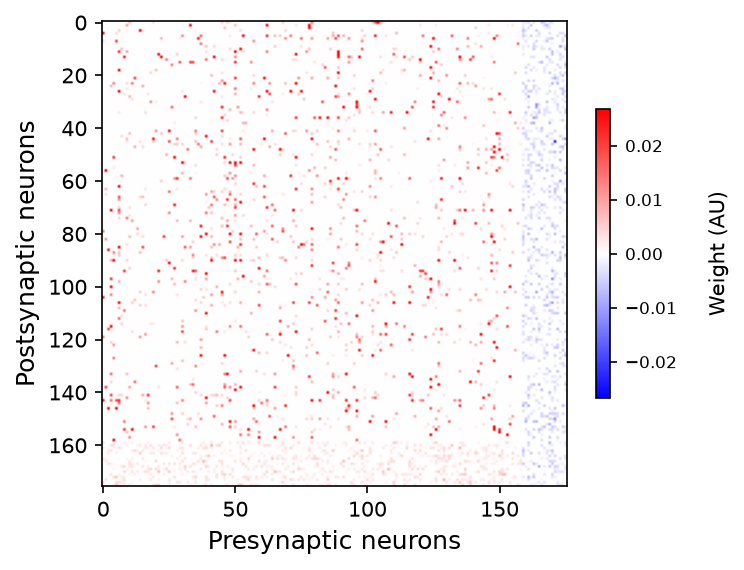

EE mean:  0.0003215434083601287
IE mean:  0.00035369774919614147
EI mean:  -0.0004852941176470589
II mean:  -0.0004411764705882353


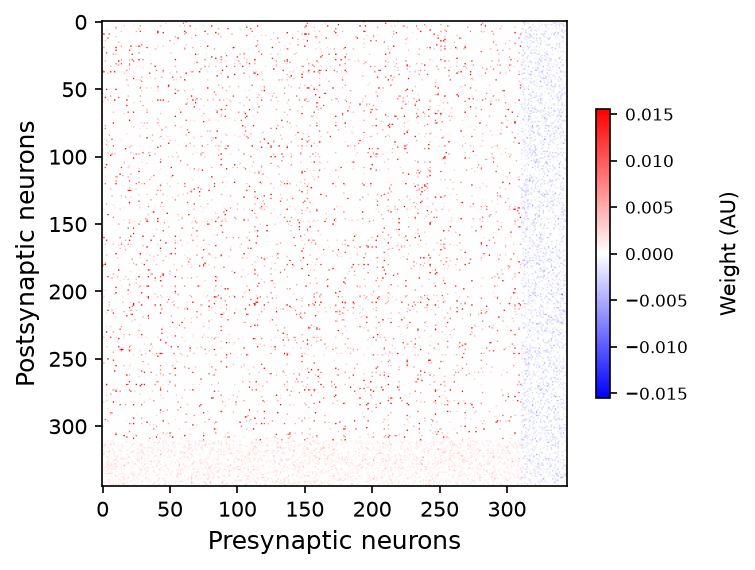

In [17]:
# Connectivity parameters
g = .002  # overall gain of connectivity
connectivity_proba = .25 # Likelihood of two neurons to be connected with each other
r_inhibitory = .10 # Ratio of inhibitory neurons
inh_exc_balance = .15 # Result of I/E for every neuron's input

# Simulation parameters
t_max = 50 # Length of simulation
dt = 0.01 # Simulation time step
t_stimulus_start = 1 # Stimulus start time
t_stimulus_end = 15 # Stimulus end time
stim_strength = 10 # Stimulus strength rate
tau = .25 # Neuron time constant

# Simulation variables
n_steps = int(t_max / dt)

random_seed = 42

W2 = observed_plus_random_connectivity_matrix_random_inh(syn_mat_l2, r_inhibitory=r_inhibitory, g=50*g,
                                             connectivity_proba=connectivity_proba, random_seed=random_seed,
                                             inh_exc_balance=inh_exc_balance)
plot_matrix(W2)

W3 = observed_plus_random_connectivity_matrix_random_inh(syn_mat_l3, r_inhibitory=r_inhibitory, g=50*g,
                                             connectivity_proba=connectivity_proba, random_seed=random_seed,
                                             inh_exc_balance=inh_exc_balance)
plot_matrix(W3)

W4 = observed_plus_random_connectivity_matrix_random_inh(syn_mat_l4, r_inhibitory=r_inhibitory, g=50*g,
                                             connectivity_proba=connectivity_proba, random_seed=random_seed,
                                             inh_exc_balance=inh_exc_balance)
plot_matrix(W4)

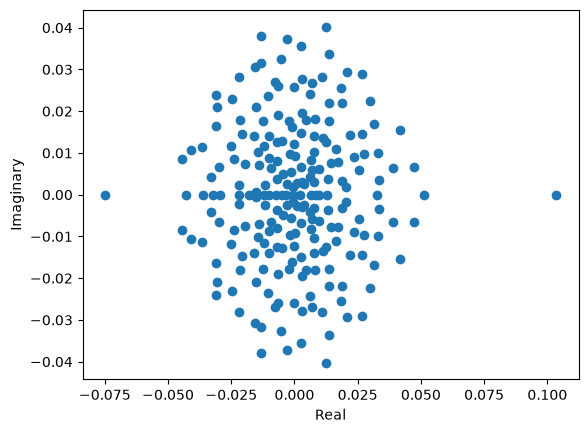

Condition number of eigenvector matrix for W2: 808.293647518798


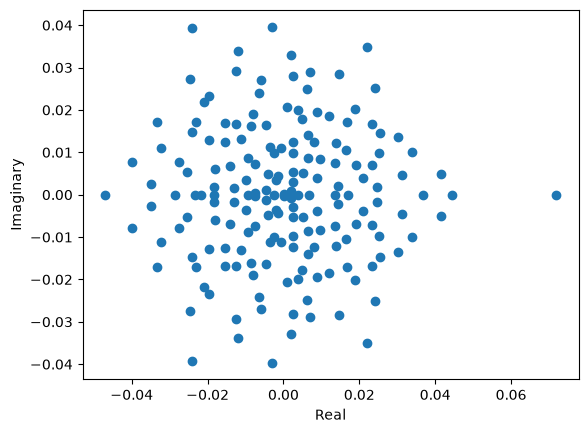

Condition number of eigenvector matrix for W3: 332.66446388267474


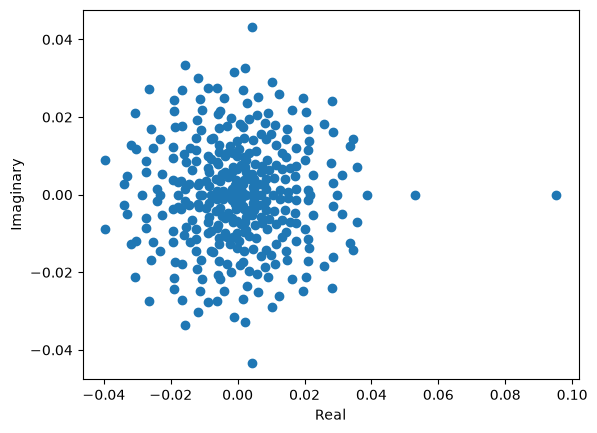

Condition number of eigenvector matrix for W4: 437.59814581798327


In [48]:
from numpy import linalg as LA
A2 = W2 - np.eye(len(W2))
eigenvalues, eigenvectors = LA.eig(W2)
x = [ele.real for ele in eigenvalues]
# extract imaginary part
y = [ele.imag for ele in eigenvalues]

# plot the complex numbers
plt.scatter(x, y)
plt.ylabel('Imaginary')
plt.xlabel('Real')
plt.show()

#condition number of eigenvector matrix
cond2 = np.linalg.cond(eigenvectors)
print("Condition number of eigenvector matrix for W2:", cond)

A3 = W3 - np.eye(len(W3))
eigenvalues, eigenvectors = LA.eig(W3)
x = [ele.real for ele in eigenvalues]
y = [ele.imag for ele in eigenvalues]

plt.scatter(x, y)
plt.ylabel('Imaginary')
plt.xlabel('Real')
plt.show()

cond3 = np.linalg.cond(eigenvectors)
print("Condition number of eigenvector matrix for W3:", cond3)

A4 = W4 - np.eye(len(W4))
eigenvalues, eigenvectors = LA.eig(W4)
x = [ele.real for ele in eigenvalues]
y = [ele.imag for ele in eigenvalues]

plt.scatter(x, y)
plt.ylabel('Imaginary')
plt.xlabel('Real')
plt.show()

cond4 = np.linalg.cond(eigenvectors)
print("Condition number of eigenvector matrix for W4:", cond4)

## plotting metric

eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561


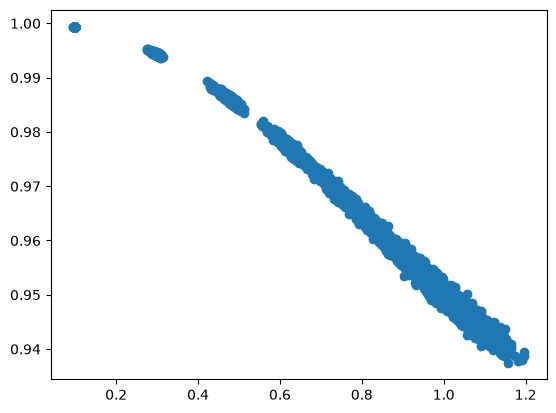

eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.85724

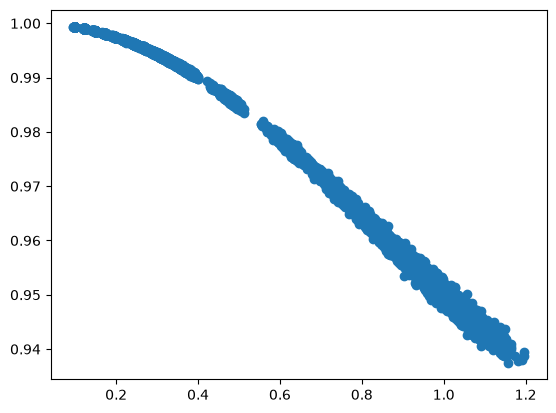

eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561
eps: 0.8572402161055561
done with first int
eps: 0.8572402161055561
eps: 0.8572402161055561


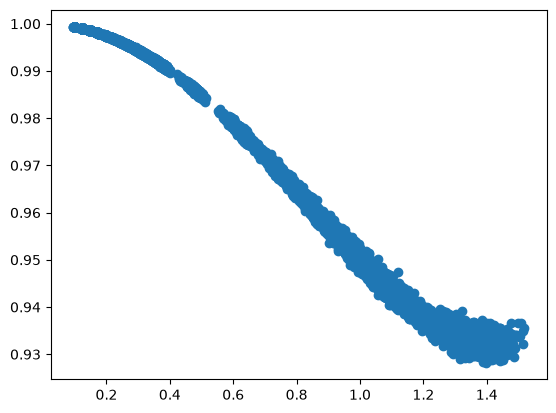

In [26]:
A2 = W2 - np.eye(len(W2))
vdists = []
eAv_ints = []
for r in np.linspace(0.1,2,10):
    N = 1000

    eAv_ints_r, vs, rats = rand_v_ints_vstar(A2,N,r=r)
    v = calc_vstar(A2)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

for r in np.linspace(0.125,.4,12):
    N = 1000

    eAv_ints_r, vs, rats = rand_v_ints_vstar(A2,N,r=r)
    v = calc_vstar(A2)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

for r in np.linspace(2.5,15,4):
    N = 1000

    eAv_ints_r, vs, rats = rand_v_ints_vstar(A2,N,r=r)
    v = calc_vstar(A2)
    vdists_r = [np.linalg.norm(vs[i] - v) for i in range(len(vs))]
    vdists.append(vdists_r)
    eAv_ints.append(eAv_ints_r)

plt.scatter(np.array(vdists).flatten(), np.array(eAv_ints).flatten())
plt.show()

In [27]:
def henrici_departure(A):
    """Henrici’s departure from normality"""
    fro_norm_sq = np.linalg.norm(A, ord="fro") ** 2
    eig_norm_sq = np.sum(np.abs(linalg.eigvals(A)) ** 2)
    return np.sqrt(fro_norm_sq - eig_norm_sq.real) / np.linalg.norm(A, ord="fro")

In [67]:
print("Henrici's departure from normality for W2:", henrici_departure(W2))
print("Henrici's departure from normality for W3:", henrici_departure(W3))
print("Henrici's departure from normality for W4:", henrici_departure(W4))

print("Henrici's departure from normality for W:", henrici_departure(W))
print("Henrici's departure from normality for W_er:", henrici_departure(W_er))
print("Henrici's departure from normality for W_er_unif:", henrici_departure(W_er_unif))

Henrici's departure from normality for W2: 0.8100724343905104
Henrici's departure from normality for W3: 0.8446538559304316
Henrici's departure from normality for W4: 0.8169065206203284
Henrici's departure from normality for W: 0.8247773286055419
Henrici's departure from normality for W_er: 0.7170736309092446
Henrici's departure from normality for W_er_unif: 0.717675305435975


In [ ]:
#plot pseudospectra
